# EDA & Preprocessing Notebook
## Cognitive Fatigue & Digital Habits Dataset

**Deskripsi:**  
Notebook ini menggabungkan seluruh tahap **Exploratory Data Analysis (EDA)** dan **Preprocessing**

**Alur Notebook:**
1. Setup & Install Dependencies
2. Import Library
3. Load Data
4. Inspeksi Awal & Data Dictionary
5. Pemeriksaan Kualitas Data
6. Statistik Deskriptif
7. Distribusi Variabel
8. Deteksi Outlier
9. Analisis Variabel Kategorik
10. Analisis Korelasi
11. Analisis Pertanyaan Penelitian (RQ 1–6)
12. Mapping Dataset
13. Kesimpulan EDA
14. ──── PREPROCESSING ────
15. Feature Engineering
16. Encoding Variabel Kategorik
17. Train-Test Split
18. Oversampling (Training Only)
19. Feature Scaling
20. Simpan Dataset Final


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [2]:
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_cognitive_fatigue_dataset.csv to cleaned_cognitive_fatigue_dataset.csv


## 2. Load Data & Inspeksi Awal

In [4]:
df = pd.read_csv('cleaned_cognitive_fatigue_dataset.csv')

print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"Total sel data : {df.shape[0] * df.shape[1]}")

Jumlah baris   : 98535
Jumlah kolom   : 12
Total sel data : 1182420


In [5]:
df.head(10)

,screen_time,sleep_hours,stress_level,wellness_index,sleep_quality,fatigue_score,digital_balance,screen_time_category,physical_activity,caffeine_intake,work_hours,mood
0,10.79,6.63,9.3,9.3,Moderate,6.710,0.562341,High,1,1,6,Exhausted
1,7.40,8.05,5.7,56.2,Good,3.630,0.958333,Moderate,4,1,9,Normal
2,9.78,6.48,9.1,3.6,Moderate,6.256,0.601113,High,2,1,5,Exhausted
3,11.13,6.89,10.0,0.0,Moderate,7.074,0.568013,High,3,0,9,Exhausted
4,13.22,5.79,10.0,0.0,Moderate,8.130,0.407173,High,4,1,8,Exhausted
5,9.83,7.19,10.0,5.0,Good,6.494,0.663897,High,0,2,5,Exhausted
6,6.02,7.44,6.1,43.7,Good,3.360,1.059829,Moderate,0,2,12,Normal
7,6.21,6.78,5.4,54.3,Moderate,3.288,0.940361,Moderate,2,3,9,Normal
8,6.28,8.48,1.6,86.8,Good,1.456,1.164835,Moderate,4,2,4,Relaxed
9,9.37,7.78,10.0,10.7,Good,6.192,0.750241,High,0,2,5,Exhausted


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98535 entries, 0 to 98534
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   screen_time           98535 non-null  float64
 1   sleep_hours           98535 non-null  float64
 2   stress_level          98535 non-null  float64
 3   wellness_index        98535 non-null  float64
 4   sleep_quality         98535 non-null  object 
 5   fatigue_score         98535 non-null  float64
 6   digital_balance       98535 non-null  float64
 7   screen_time_category  98535 non-null  object 
 8   physical_activity     98535 non-null  int64  
 9   caffeine_intake       98535 non-null  int64  
 10  work_hours            98535 non-null  int64  
 11  mood                  98535 non-null  object 
dtypes: float64(6), int64(3), object(3)
memory usage: 9.0+ MB


In [7]:
df.dtypes

,0
screen_time,float64
sleep_hours,float64
stress_level,float64
wellness_index,float64
sleep_quality,object
fatigue_score,float64
digital_balance,float64
screen_time_category,object
physical_activity,int64
caffeine_intake,int64


## 3. Data Dictionary

Tabel berikut menjelaskan setiap variabel dalam dataset beserta tipe data dan satuannya.

| Variabel | Tipe | Keterangan |
|---|---|---|
| `screen_time` | Float | Durasi penggunaan layar per hari (jam) |
| `sleep_hours` | Float | Durasi tidur per hari (jam) |
| `stress_level` | Float/Int | Skor tingkat stres (skala 0–10) |
| `wellness_index` | Float | Indeks kesehatan mental keseluruhan (skala 0–100) |
| `physical_activity` | Float/Int | Durasi aktivitas fisik per hari (jam) |
| `fatigue_score` | Float/Int | Skor kelelahan kognitif (skala 0–100) |
| `mood` | Object | Kondisi suasana hati pengguna (kategorik) |
| `fatigue_level` | Object | Label kelas target: refreshed / strained / near-burnout |


## 4. Pemeriksaan Kualitas Data

### 4.1 Missing Value

In [8]:
# Menghitung jumlah dan persentase missing value
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct
})
print(missing_df[missing_df['Jumlah Missing'] > 0] if missing_df['Jumlah Missing'].sum() > 0 else "Tidak ada missing value.")
print(f"\nTotal missing value: {df.isnull().sum().sum()}")

Tidak ada missing value.

Total missing value: 0


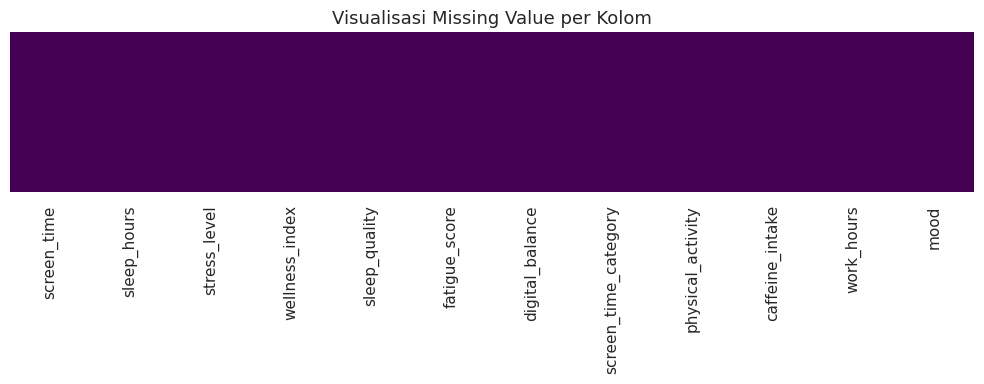

In [9]:
# Heatmap visualisasi missing value
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Visualisasi Missing Value per Kolom', fontsize=13)
plt.tight_layout()
plt.show()

**Insight:** Pemeriksaan missing value dilakukan untuk memastikan kelengkapan data. Jika ditemukan missing value, perlu diputuskan apakah akan diimputasi atau dihapus tergantung persentase dan konteksnya. Visualisasi heatmap memudahkan identifikasi pola missing value secara visual.

### 4.2 Data Duplikat

In [10]:
# Mengecek jumlah data duplikat
n_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat : {n_duplikat}")
print(f"Persentase duplikat   : {n_duplikat / len(df) * 100:.2f}%")

Jumlah baris duplikat : 920
Persentase duplikat   : 0.93%


**Insight:** Data duplikat dapat menyebabkan bias pada analisis dan overfitting pada pemodelan. Jika ditemukan duplikat, baris tersebut perlu dihapus sebelum analisis lanjutan.

### 4.3 Nilai Unik per Kolom

In [11]:
# Ringkasan nilai unik setiap kolom
unique_summary = pd.DataFrame({
    'Jumlah Nilai Unik': df.nunique(),
    'Tipe Data': df.dtypes
})
print(unique_summary)

                      Jumlah Nilai Unik Tipe Data
screen_time                         398   float64
sleep_hours                         301   float64
stress_level                         82   float64
wellness_index                      270   float64
sleep_quality                         3    object
fatigue_score                     15247   float64
digital_balance                    5186   float64
screen_time_category                  3    object
physical_activity                     5     int64
caffeine_intake                       4     int64
work_hours                            9     int64
mood                                  3    object


### 4.4 Rentang Nilai (Min & Max)

In [12]:
# Analisis rentang nilai data numerik
numeric_cols = df.select_dtypes(include='number').columns

range_data = []
for col in numeric_cols:
    range_data.append({
        'Variabel': col,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Range': df[col].max() - df[col].min()
    })

range_df = pd.DataFrame(range_data).set_index('Variabel')
print(range_df)

                    Min    Max  Range
Variabel                             
screen_time        1.00  19.17  18.17
sleep_hours        0.00   9.74   9.74
stress_level       0.00  10.00  10.00
wellness_index     0.00  97.00  97.00
fatigue_score     -1.07  10.33  11.40
digital_balance    0.00   3.63   3.63
physical_activity  0.00   4.00   4.00
caffeine_intake    0.00   3.00   3.00
work_hours         4.00  12.00   8.00


**Insight:** Pemeriksaan rentang nilai membantu mendeteksi kemungkinan nilai yang tidak wajar atau kesalahan input. Misalnya, nilai screen_time yang melebihi 24 jam per hari perlu dicurigai sebagai error.

## 5. Statistik Deskriptif

In [13]:
df.describe()

,screen_time,sleep_hours,stress_level,wellness_index,fatigue_score,digital_balance,physical_activity,caffeine_intake,work_hours
count,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000,98535.000000
mean,6.029388,0.594462,0.608154,0.960015,2.536124,0.092364,1.996854,1.502502,7.988156
std,2.002610,0.463438,0.548868,1.798835,0.875072,0.068790,1.410711,1.117923,2.583584
min,1.000000,0.000000,0.000000,0.000000,-1.070000,0.000000,0.000000,0.000000,4.000000
25%,4.700000,0.428571,0.444444,0.750000,1.947937,0.057915,1.000000,1.000000,6.000000
50%,6.000000,0.571429,0.555556,1.000000,2.525397,0.081395,2.000000,2.000000,8.000000
75%,7.400000,0.714286,0.777778,1.000000,3.106984,0.111380,3.000000,3.000000,10.000000
max,19.170000,9.740000,10.000000,97.000000,10.330000,3.630000,4.000000,3.000000,12.000000


In [14]:
# Statistik deskriptif detail: mean, median, std, skewness, kurtosis
numeric_df = df.select_dtypes(include='number')

stats_summary = pd.DataFrame({
    'Mean'     : numeric_df.mean(),
    'Median'   : numeric_df.median(),
    'Std Dev'  : numeric_df.std(),
    'Skewness' : numeric_df.skew(),
    'Kurtosis' : numeric_df.kurtosis()
}).round(4)

print("Ringkasan Statistik Deskriptif:")
print(stats_summary)

Ringkasan Statistik Deskriptif:
                     Mean  Median  Std Dev  Skewness  Kurtosis
screen_time        6.0294  6.0000   2.0026    0.0606   -0.1031
sleep_hours        0.5945  0.5714   0.4634   11.3124  162.4548
stress_level       0.6082  0.5556   0.5489   12.6549  197.0871
wellness_index     0.9600  1.0000   1.7988   29.0463  999.4238
fatigue_score      2.5361  2.5254   0.8751    0.2865    1.0724
digital_balance    0.0924  0.0814   0.0688    8.9966  226.6635
physical_activity  1.9969  2.0000   1.4107   -0.0002   -1.2952
caffeine_intake    1.5025  2.0000   1.1179   -0.0041   -1.3597
work_hours         7.9882  8.0000   2.5836    0.0029   -1.2296


**Insight:**
- **Mean vs Median:** Jika terdapat perbedaan besar antara mean dan median, ini mengindikasikan adanya nilai ekstrem (outlier) yang menarik rata-rata.
- **Skewness:** Nilai positif berarti data condong ke kanan (heavy-right tail), negatif condong ke kiri. Nilai |skewness| > 1 menunjukkan distribusi yang sangat miring.
- **Kurtosis:** Nilai tinggi (> 3) menunjukkan distribusi memiliki ekor yang lebih berat dari distribusi normal (leptokurtic), artinya ada lebih banyak nilai ekstrem.

## 6. Distribusi Variabel

### 6.1 Distribusi Variabel Numerik

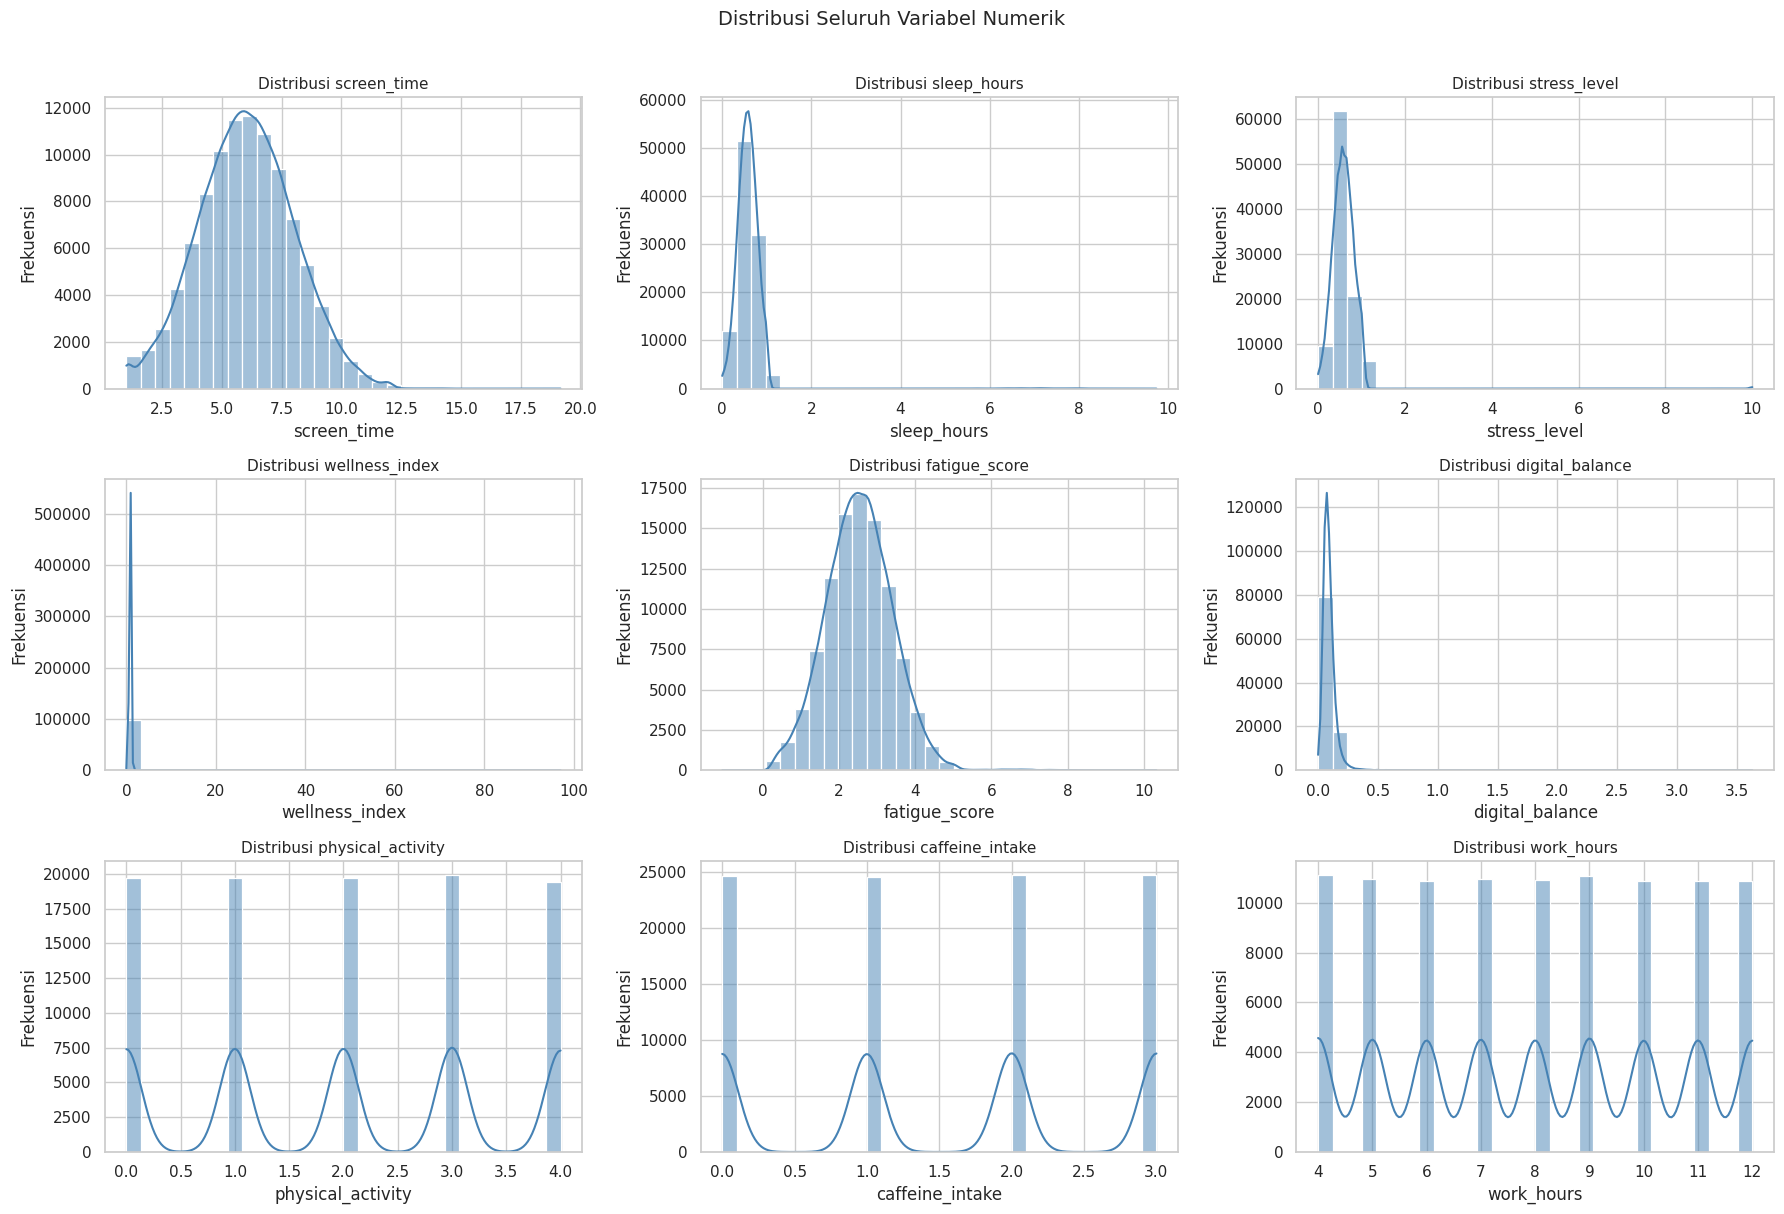

In [15]:
numeric_cols = df.select_dtypes(include='number').columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Matikan axes kosong jika ada
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Seluruh Variabel Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insight:** Visualisasi distribusi membantu memahami sebaran data setiap variabel. Perhatikan apakah distribusi mendekati normal, memiliki skewness, atau terdapat puncak ganda (bimodal) yang bisa mengindikasikan adanya subgroup dalam data.

### 6.2 Distribusi Target Variable (fatigue_level)

Info: kolom fatigue_level dibuat sementara dari fatigue_score untuk visualisasi EDA.


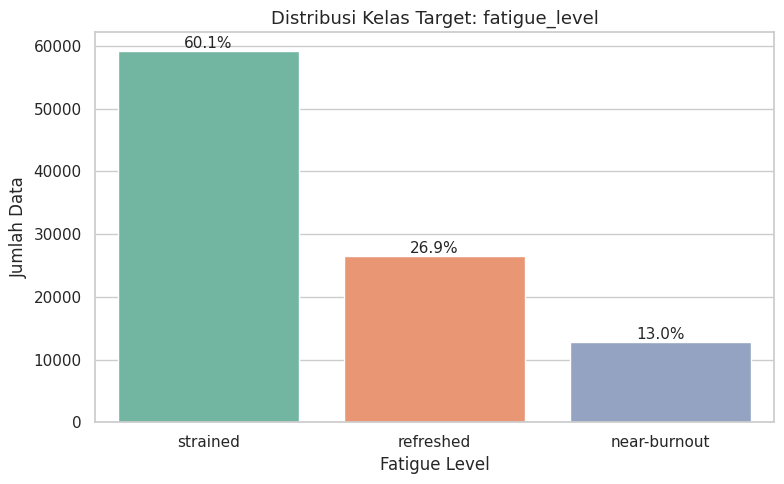


Distribusi absolut:
fatigue_level
strained        59190
refreshed       26521
near-burnout    12824
Name: count, dtype: int64

Distribusi relatif (%):
fatigue_level
strained        60.07
refreshed       26.92
near-burnout    13.01
Name: proportion, dtype: float64


In [16]:
# Distribusi kelas target
# fatigue_level dibuat dari fatigue_score di bagian Preprocessing.
# Jika kolom belum ada, gunakan fatigue_score sebagai gambaran distribusi awal.

def fatigue_label(score):
    if score <= 2.0:
        return 'refreshed'
    elif score <= 3.5:
        return 'strained'
    else:
        return 'near-burnout'

# Buat kolom sementara khusus untuk visualisasi EDA (tidak mengubah df asli)
df_eda = df.copy()
if 'fatigue_level' not in df_eda.columns:
    if 'fatigue_score' in df_eda.columns:
        df_eda['fatigue_level'] = df_eda['fatigue_score'].apply(fatigue_label)
        print("Info: kolom fatigue_level dibuat sementara dari fatigue_score untuk visualisasi EDA.")
    else:
        print("Kolom fatigue_score tidak ditemukan. Lewati cell ini.")
        df_eda = None

if df_eda is not None:
    plt.figure(figsize=(8, 5))
    order = df_eda['fatigue_level'].value_counts().index
    ax = sns.countplot(x='fatigue_level', data=df_eda, order=order, palette='Set2')

    total = len(df_eda)
    for p in ax.patches:
        pct = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11)

    plt.title('Distribusi Kelas Target: fatigue_level', fontsize=13)
    plt.xlabel('Fatigue Level')
    plt.ylabel('Jumlah Data')
    plt.tight_layout()
    plt.show()

    print("\nDistribusi absolut:")
    print(df_eda['fatigue_level'].value_counts())
    print("\nDistribusi relatif (%):")
    print((df_eda['fatigue_level'].value_counts(normalize=True) * 100).round(2))

**Insight:** Analisis distribusi kelas target sangat penting untuk menentukan apakah dataset mengalami class imbalance. Jika salah satu kelas jauh lebih dominan, teknik seperti oversampling (SMOTE atau random oversampling) atau undersampling perlu diterapkan pada tahap preprocessing untuk menghindari bias model.

## 7. Analisis Variabel Kategorik

Kolom kategorik yang ditemukan: ['sleep_quality', 'screen_time_category', 'mood']


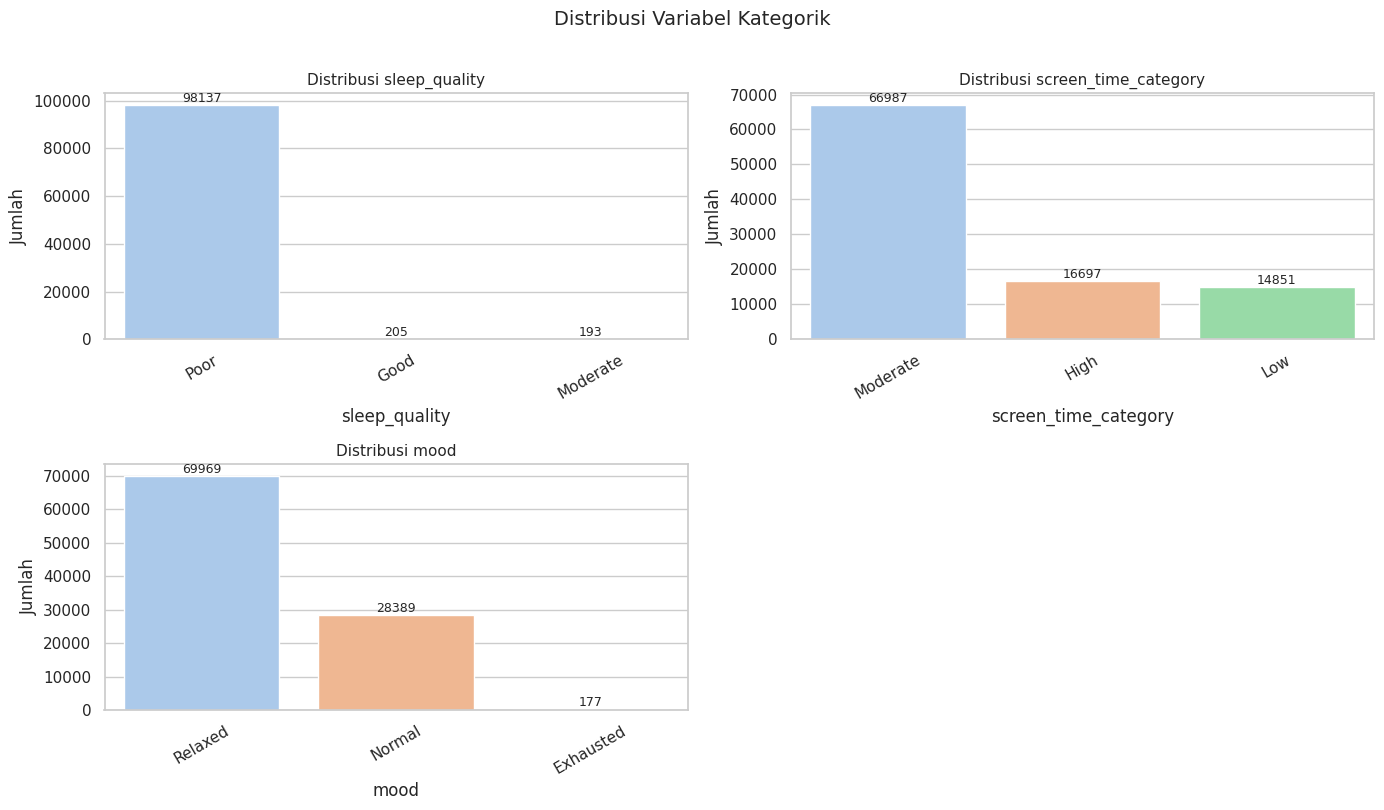


--- Frekuensi sleep_quality ---
               Jumlah  Persen (%)
sleep_quality                    
Poor            98137       99.60
Good              205        0.21
Moderate          193        0.20

--- Frekuensi screen_time_category ---
                      Jumlah  Persen (%)
screen_time_category                    
Moderate               66987       67.98
High                   16697       16.95
Low                    14851       15.07

--- Frekuensi mood ---
           Jumlah  Persen (%)
mood                         
Relaxed     69969       71.01
Normal      28389       28.81
Exhausted     177        0.18


In [17]:
cat_cols = df.select_dtypes(include='object').columns
print(f"Kolom kategorik yang ditemukan: {list(cat_cols)}")

if len(cat_cols) == 0:
    print("Tidak ada kolom kategorik.")
else:
    n_cols_plot = 2
    n_rows_plot = int(np.ceil(len(cat_cols) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(14, n_rows_plot * 4))
    axes = axes.flatten() if n_rows_plot > 1 or n_cols_plot > 1 else [axes]

    for i, col in enumerate(cat_cols):
        order = df[col].value_counts().index
        sns.countplot(x=col, data=df, order=order, palette='pastel', ax=axes[i])
        axes[i].set_title(f'Distribusi {col}', fontsize=11)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Jumlah')
        axes[i].tick_params(axis='x', rotation=30)

        # Label nilai di atas bar
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height())}',
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribusi Variabel Kategorik', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Tabel frekuensi
    for col in cat_cols:
        print(f"\n--- Frekuensi {col} ---")
        freq = df[col].value_counts()
        freq_pct = (freq / len(df) * 100).round(2)
        print(pd.DataFrame({'Jumlah': freq, 'Persen (%)': freq_pct}))

**Insight:** Analisis variabel kategorik menunjukkan frekuensi tiap kategori. Kategori yang sangat dominan atau sangat jarang perlu diperhatikan karena dapat mempengaruhi generalisasi model.

## 8. Deteksi Outlier

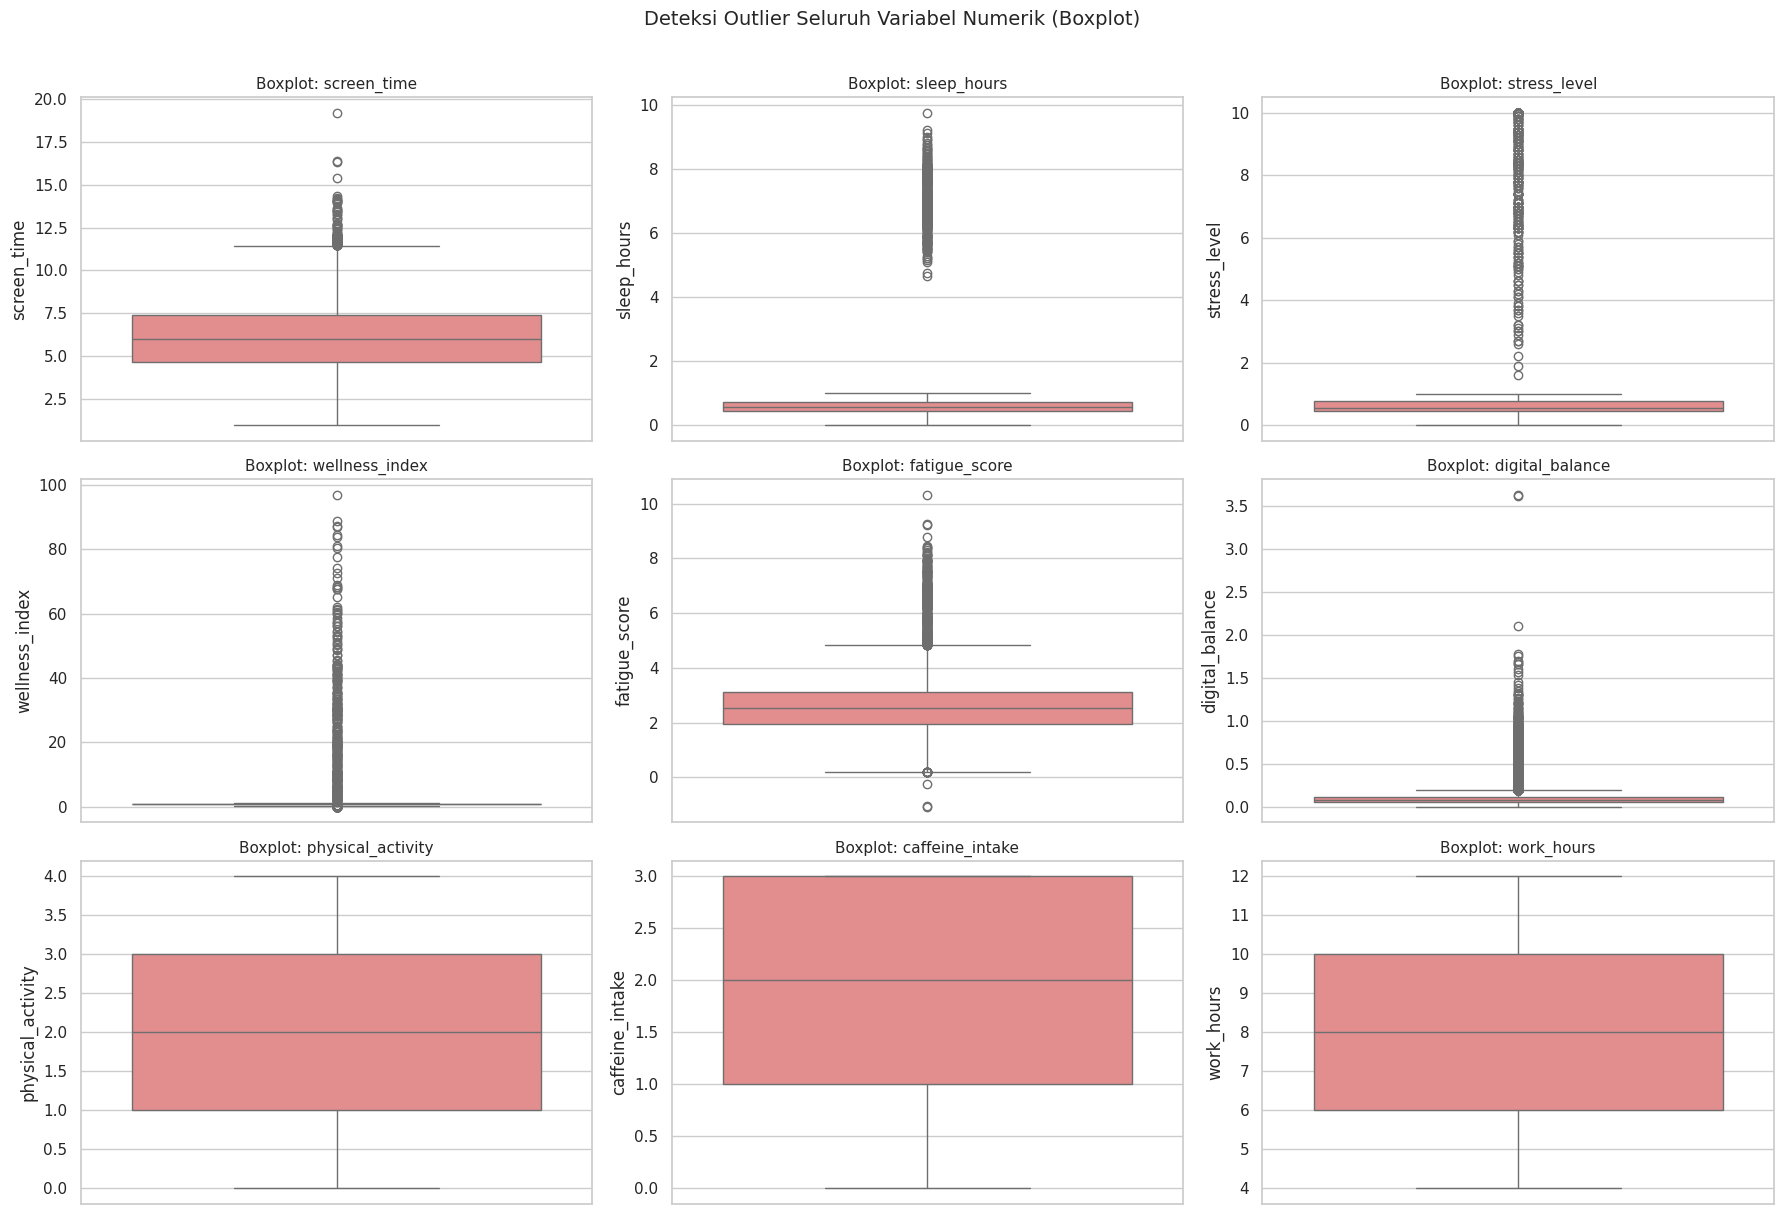

In [18]:
# Boxplot seluruh variabel numerik
numeric_cols = df.select_dtypes(include='number').columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier Seluruh Variabel Numerik (Boxplot)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretasi Boxplot:** Boxplot di atas memperlihatkan sebaran dan potensi outlier setiap variabel numerik secara visual. Garis tengah kotak merepresentasikan median, batas bawah/atas kotak adalah Q1 dan Q3, sedangkan titik-titik di luar whisker (±1.5×IQR) merupakan kandidat outlier. Kuantifikasi jumlah outlier dilakukan pada sel berikutnya menggunakan metode IQR.

In [19]:
# Menghitung jumlah dan persentase outlier dengan metode IQR
target_cols = ['screen_time', 'sleep_hours', 'stress_level', 'wellness_index', 'physical_activity']

print("Ringkasan Outlier per Kolom (Metode IQR):\n")
print(f"{'Variabel':<20} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Jumlah Outlier':>15} {'Persen (%)':>12}")
print("-" * 75)

outlier_summary = []
for col in target_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
    pct    = n_out / len(df) * 100
    outlier_summary.append({
        'Variabel': col, 'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
        'IQR': round(IQR, 3), 'Jumlah Outlier': n_out, 'Persen (%)': round(pct, 2)
    })
    print(f"{col:<20} {Q1:>8.3f} {Q3:>8.3f} {IQR:>8.3f} {n_out:>15} {pct:>11.2f}%")

Ringkasan Outlier per Kolom (Metode IQR):

Variabel                   Q1       Q3      IQR  Jumlah Outlier   Persen (%)
---------------------------------------------------------------------------
screen_time             4.700    7.400    2.700             358        0.36%
sleep_hours             0.429    0.714    0.286             400        0.41%
stress_level            0.444    0.778    0.333             397        0.40%
wellness_index          0.750    1.000    0.250             792        0.80%
physical_activity       1.000    3.000    2.000               0        0.00%


**Insight:** Outlier dideteksi menggunakan metode IQR (Interquartile Range). Pada penelitian ini, outlier tidak langsung dihapus karena nilai ekstrem seperti screen_time yang sangat tinggi atau sleep_hours yang sangat rendah masih merepresentasikan kondisi nyata pengguna. Keputusan penanganan outlier akan dipertimbangkan pada tahap preprocessing berdasarkan persentase dan dampaknya terhadap model.

## 9. Analisis Korelasi

### 9.1 Heatmap Korelasi Antar Variabel

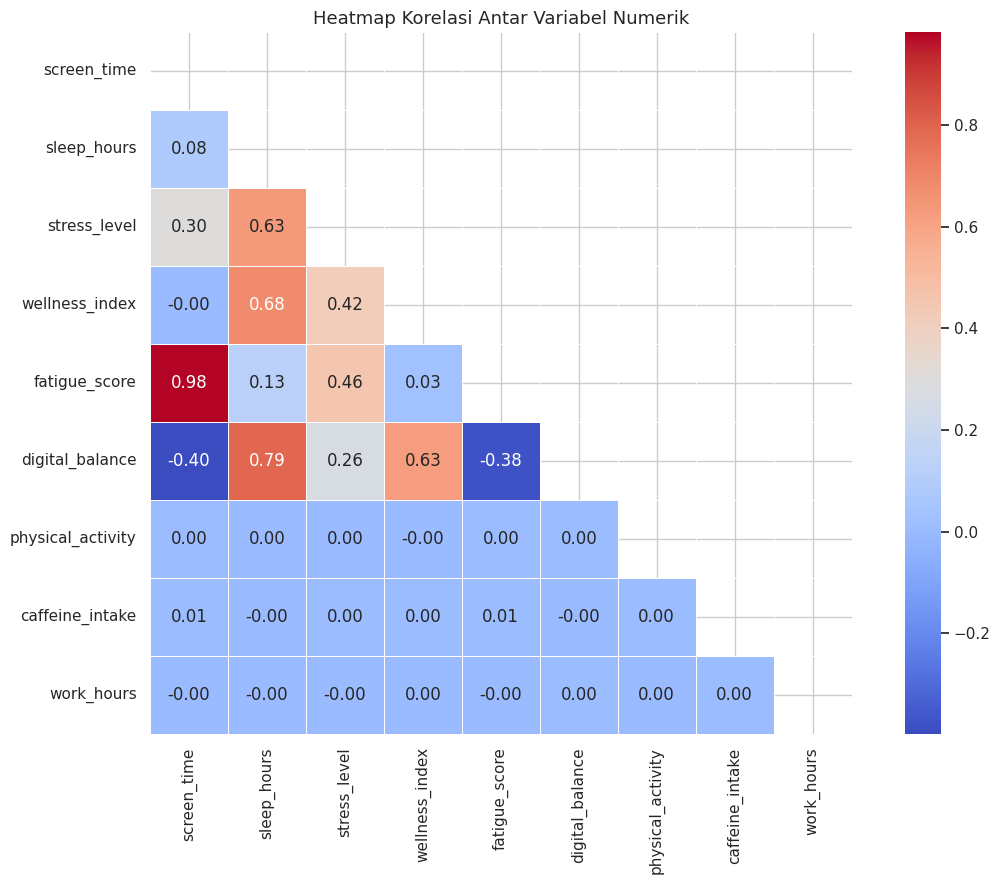

In [20]:
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(correlation, dtype=bool))  # tampilkan segitiga bawah saja
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    mask=mask,
    linewidths=0.5,
    square=True
)
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=13)
plt.tight_layout()
plt.show()

**Insight:** Heatmap korelasi menunjukkan kekuatan dan arah hubungan linear antar variabel numerik.
- Nilai mendekati **+1** menunjukkan hubungan positif yang kuat (keduanya naik bersama).
- Nilai mendekati **-1** menunjukkan hubungan negatif yang kuat (satu naik, yang lain turun).
- Nilai mendekati **0** menunjukkan tidak ada hubungan linear yang signifikan.

Pola yang diamati: screen_time cenderung berkorelasi positif dengan stress_level, sleep_hours berkorelasi positif dengan wellness_index, dan stress_level berkorelasi negatif dengan wellness_index.

### 9.2 Korelasi Terhadap Wellness Index (Bar Chart)

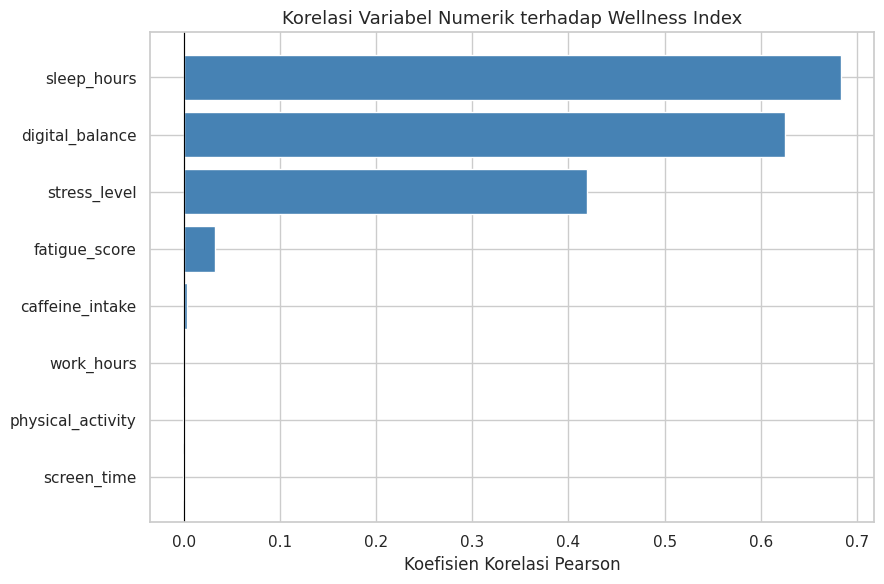


Ranking Korelasi terhadap Wellness Index:
screen_time         -0.000774
physical_activity   -0.000200
work_hours           0.000723
caffeine_intake      0.003728
fatigue_score        0.032188
stress_level         0.419641
digital_balance      0.625395
sleep_hours          0.683415


In [21]:
# Korelasi setiap variabel terhadap wellness_index
if 'wellness_index' in df.columns:
    corr_target = numeric_df.corr()['wellness_index'].drop('wellness_index').sort_values()

    colors = ['tomato' if v < 0 else 'steelblue' for v in corr_target]

    plt.figure(figsize=(9, 6))
    bars = plt.barh(corr_target.index, corr_target.values, color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Korelasi Variabel Numerik terhadap Wellness Index', fontsize=13)
    plt.xlabel('Koefisien Korelasi Pearson')
    plt.tight_layout()
    plt.show()

    print("\nRanking Korelasi terhadap Wellness Index:")
    print(corr_target.to_string())

**Insight:** Variabel dengan korelasi tertinggi terhadap wellness_index merupakan kandidat fitur paling informatif untuk pemodelan. Visualisasi ini langsung mendukung keputusan desain UI: fitur dengan korelasi tertinggi sebaiknya ditampilkan paling atas (prinsip F-pattern layout).

### 9.3 Pairplot Variabel Kunci

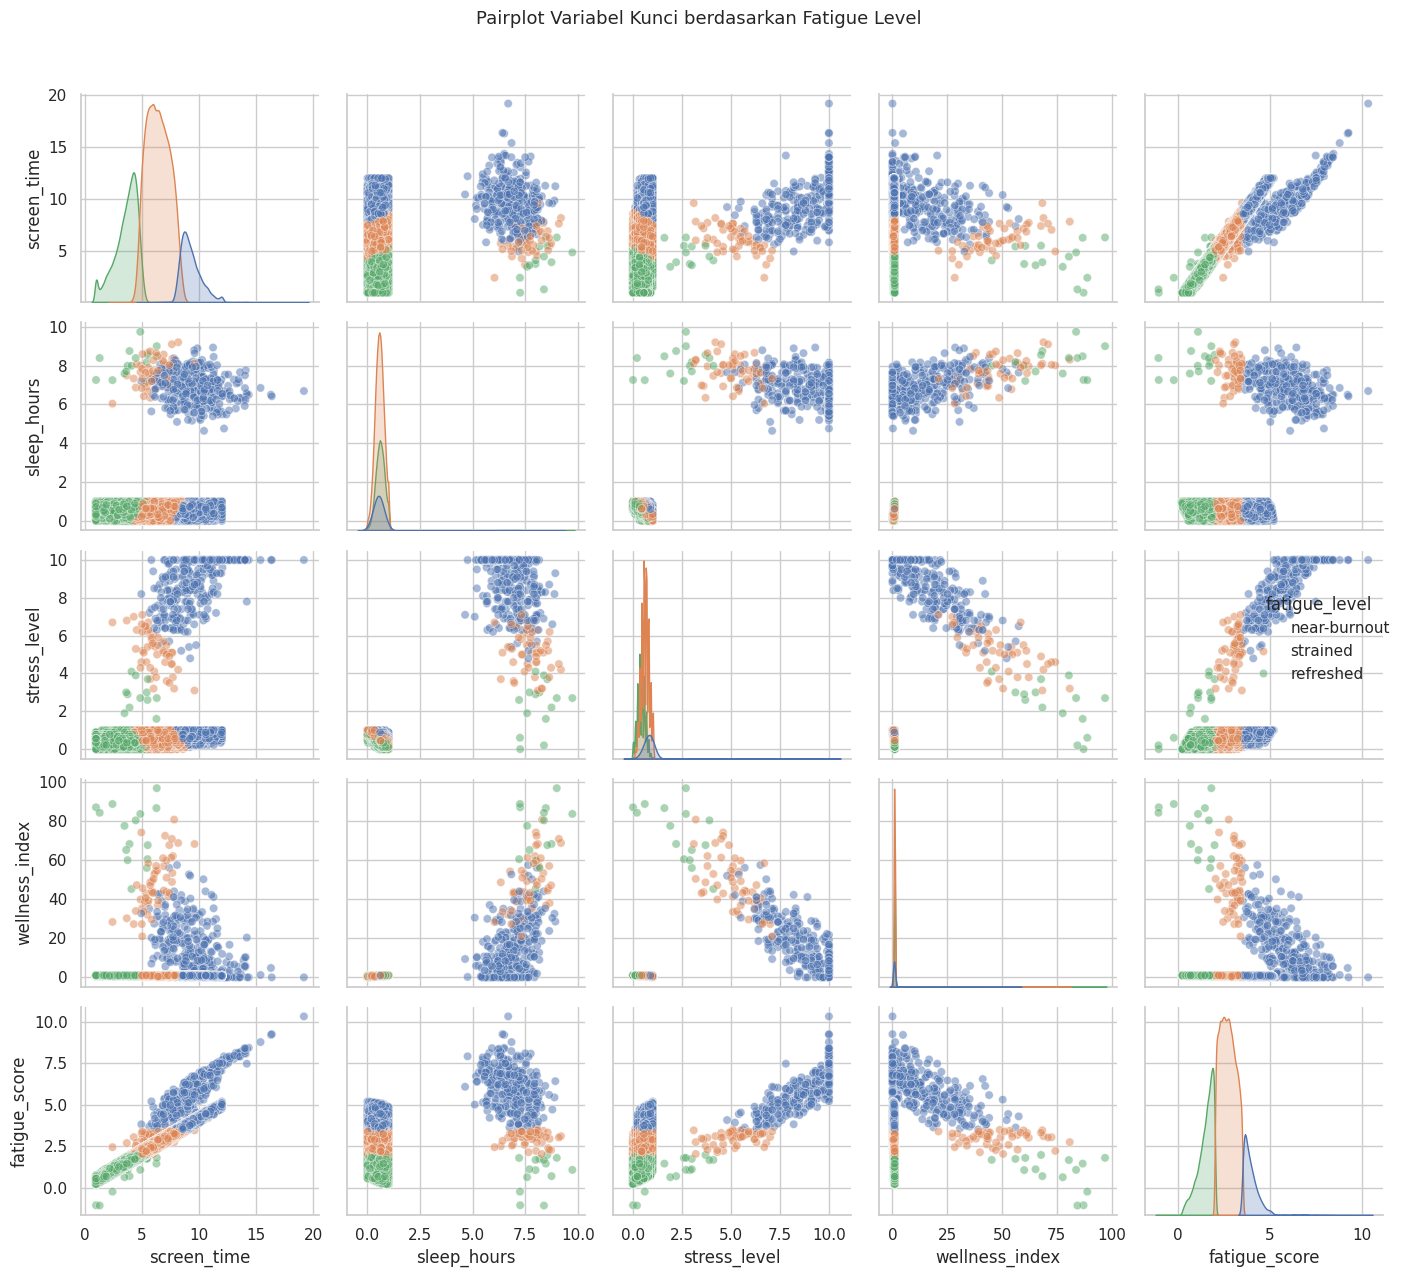

In [22]:
# Pairplot untuk melihat hubungan antar variabel kunci sekaligus
key_vars = ['screen_time', 'sleep_hours', 'stress_level', 'wellness_index', 'fatigue_score']
key_vars_exist = [v for v in key_vars if v in df.columns]

# Gunakan df_eda jika tersedia (sudah punya kolom fatigue_level sementara)
df_plot = df_eda if 'df_eda' in dir() and df_eda is not None else df
hue_col = 'fatigue_level' if 'fatigue_level' in df_plot.columns else None

sns.pairplot(
    df_plot[key_vars_exist + ([hue_col] if hue_col else [])],
    hue=hue_col,
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairplot Variabel Kunci berdasarkan Fatigue Level', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Insight:** Pairplot memvisualisasikan distribusi dan hubungan antar variabel kunci secara bersamaan, dengan warna berbeda untuk setiap kelas fatigue_level. Pemisahan warna yang jelas antar kelas mengindikasikan variabel tersebut akan menjadi fitur yang baik untuk klasifikasi.

## 10. Analisis Pertanyaan Penelitian (Research Questions)

### RQ 1: Bagaimana hubungan Screen Time terhadap Stress Level?

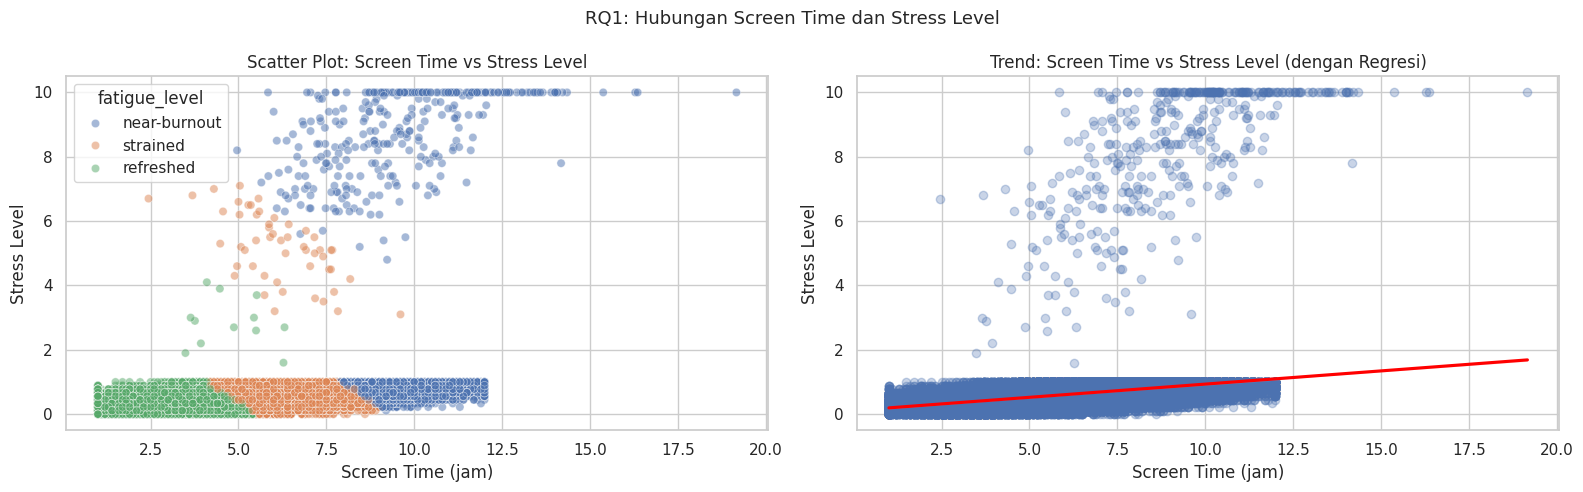

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_plot = df_eda if 'df_eda' in dir() and df_eda is not None else df
hue_col = 'fatigue_level' if 'fatigue_level' in df_plot.columns else None

# Scatter plot
sns.scatterplot(x='screen_time', y='stress_level', data=df_plot,
                alpha=0.5, hue=hue_col, ax=axes[0])
axes[0].set_title('Scatter Plot: Screen Time vs Stress Level')
axes[0].set_xlabel('Screen Time (jam)')
axes[0].set_ylabel('Stress Level')

# Regression line
sns.regplot(x='screen_time', y='stress_level', data=df_plot,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Trend: Screen Time vs Stress Level (dengan Regresi)')
axes[1].set_xlabel('Screen Time (jam)')
axes[1].set_ylabel('Stress Level')

plt.suptitle('RQ1: Hubungan Screen Time dan Stress Level', fontsize=13)
plt.tight_layout()
plt.show()

**Insight RQ1:** Scatter plot menunjukkan adanya kecenderungan bahwa pengguna dengan screen_time lebih tinggi memiliki stress_level yang lebih tinggi. Garis regresi mempertegas arah hubungan ini. Namun variasi data yang besar menunjukkan bahwa screen_time bukan satu-satunya faktor penentu stres, sehingga analisis multivariat diperlukan.

### RQ 2: Bagaimana Hubungan Sleep Hours terhadap Wellness Index?

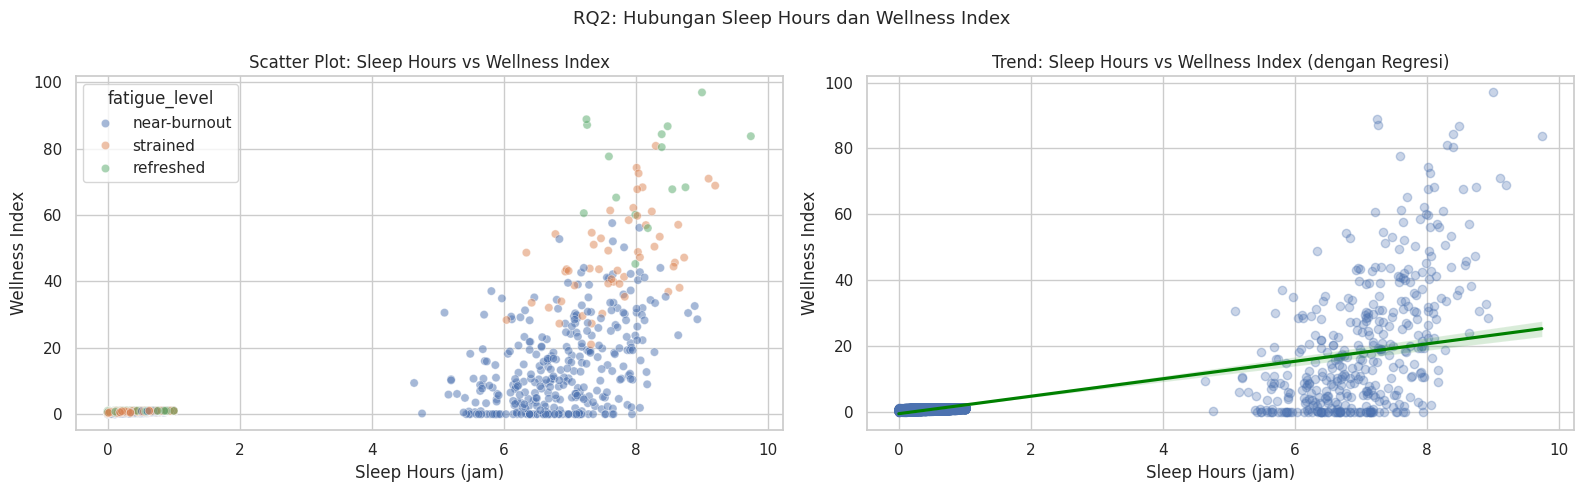

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_plot = df_eda if 'df_eda' in dir() and df_eda is not None else df
hue_col = 'fatigue_level' if 'fatigue_level' in df_plot.columns else None

sns.scatterplot(x='sleep_hours', y='wellness_index', data=df_plot,
                alpha=0.5, hue=hue_col, ax=axes[0])
axes[0].set_title('Scatter Plot: Sleep Hours vs Wellness Index')
axes[0].set_xlabel('Sleep Hours (jam)')
axes[0].set_ylabel('Wellness Index')

sns.regplot(x='sleep_hours', y='wellness_index', data=df_plot,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'green'}, ax=axes[1])
axes[1].set_title('Trend: Sleep Hours vs Wellness Index (dengan Regresi)')
axes[1].set_xlabel('Sleep Hours (jam)')
axes[1].set_ylabel('Wellness Index')

plt.suptitle('RQ2: Hubungan Sleep Hours dan Wellness Index', fontsize=13)
plt.tight_layout()
plt.show()

**Insight RQ2:** Visualisasi menunjukkan hubungan positif antara durasi tidur dan wellness index. Pengguna dengan jam tidur rendah (kurang dari 5 jam) cenderung memiliki wellness index yang lebih rendah. Temuan ini mengindikasikan bahwa sleep management merupakan salah satu intervensi paling efektif untuk meningkatkan kesehatan mental pengguna.

### RQ 3: Pada Level Screen Time Berapa Stress Level Melonjak Drastis?

**Tujuan:** Menentukan threshold untuk fitur "Smart Alert" pada sistem.

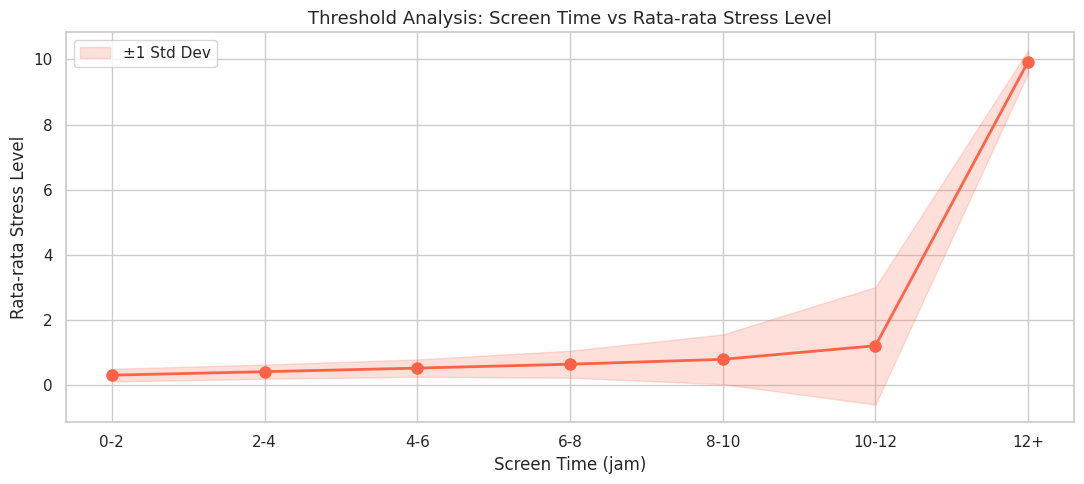


Detail rata-rata stress per bin screen time:
screen_time_bins     mean      std
             0-2 0.316176 0.195465
             2-4 0.422777 0.218735
             4-6 0.533180 0.266747
             6-8 0.652289 0.414893
            8-10 0.801903 0.762717
           10-12 1.218266 1.802313
             12+ 9.935000 0.351954


In [25]:
# Binning screen time dan analisis rata-rata stress per bin
df_temp = df.copy()
df_temp['screen_time_bins'] = pd.cut(
    df_temp['screen_time'],
    bins=[0, 2, 4, 6, 8, 10, 12, 24],
    labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12+']
)
threshold_analysis = df_temp.groupby('screen_time_bins', observed=True)['stress_level'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(11, 5))
plt.plot(threshold_analysis['screen_time_bins'].astype(str),
         threshold_analysis['mean'], marker='o', color='tomato', linewidth=2, markersize=8)
plt.fill_between(
    range(len(threshold_analysis)),
    threshold_analysis['mean'] - threshold_analysis['std'],
    threshold_analysis['mean'] + threshold_analysis['std'],
    alpha=0.2, color='tomato', label='±1 Std Dev'
)
plt.title('Threshold Analysis: Screen Time vs Rata-rata Stress Level', fontsize=13)
plt.xlabel('Screen Time (jam)')
plt.ylabel('Rata-rata Stress Level')
plt.xticks(range(len(threshold_analysis)), threshold_analysis['screen_time_bins'].astype(str))
plt.legend()
plt.tight_layout()
plt.show()

print("\nDetail rata-rata stress per bin screen time:")
print(threshold_analysis.to_string(index=False))

**Insight RQ3:** Grafik threshold memperlihatkan titik di mana rata-rata stress_level mulai naik signifikan. Jika lonjakan terjadi pada rentang 6-8 jam, maka sistem notifikasi "Take a Break" sebaiknya aktif pada saat pengguna mencapai 6 jam pemakaian layar. Pita standar deviasi menunjukkan variabilitas stress antar pengguna pada tiap bin.

### RQ 4: Profil Kebiasaan Pengguna Mood 'Exhausted' vs 'Relaxed'

**Tujuan:** Dasar personalisasi konten dan tampilan "Recovery Mode" pada dashboard.

Nilai unik mood: ['Exhausted', 'Normal', 'Relaxed']

Profil Rata-rata Kebiasaan per Mood:
           screen_time  sleep_hours  physical_activity
mood                                                  
Exhausted    11.081186     6.600282           2.000000
Relaxed       5.067696     0.583811           1.991453


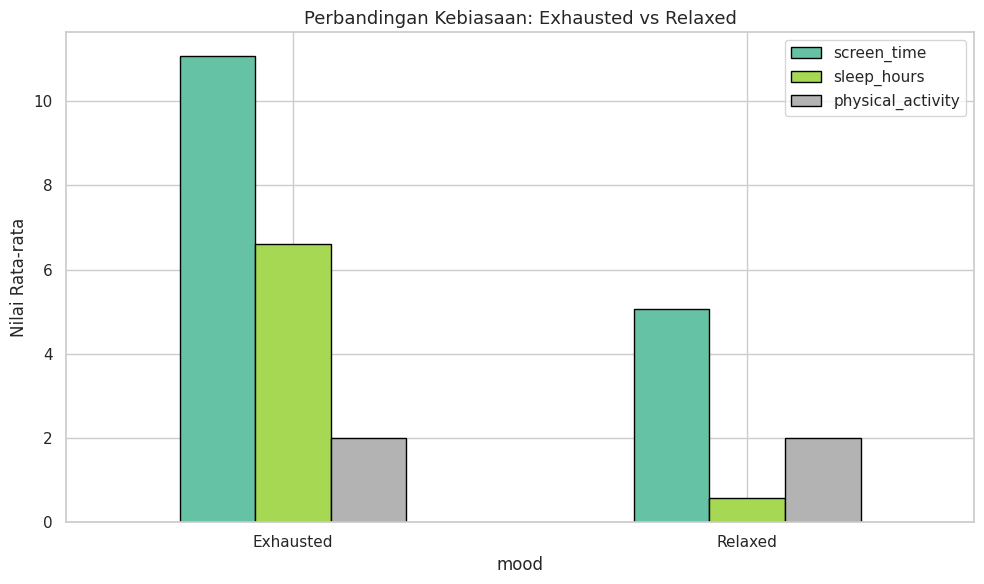

In [26]:
if 'mood' in df.columns:
    mood_vals = df['mood'].unique()
    print(f"Nilai unik mood: {list(mood_vals)}")

    # Filter dua mood target (sesuaikan label dengan dataset)
    target_moods = ['Exhausted', 'Relaxed']
    available_moods = [m for m in target_moods if m in mood_vals]

    if len(available_moods) < 2:
        # Coba case-insensitive
        mood_map = {m.lower(): m for m in mood_vals}
        available_moods = [mood_map.get(t.lower()) for t in target_moods if mood_map.get(t.lower())]

    if len(available_moods) == 2:
        segments = df[df['mood'].isin(available_moods)]
        profile_cols = [c for c in ['screen_time', 'sleep_hours', 'physical_activity'] if c in df.columns]
        profile = segments.groupby('mood')[profile_cols].mean()

        print("\nProfil Rata-rata Kebiasaan per Mood:")
        print(profile)

        profile.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
        plt.title('Perbandingan Kebiasaan: Exhausted vs Relaxed', fontsize=13)
        plt.ylabel('Nilai Rata-rata')
        plt.xticks(rotation=0)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Label mood yang tersedia: {list(mood_vals)}")
        print("Sesuaikan nama label pada variabel target_moods.")
else:
    print("Kolom 'mood' tidak ditemukan dalam dataset.")

**Insight RQ4:** Profil perbandingan menunjukkan perbedaan kebiasaan antara pengguna dengan mood "Exhausted" dan "Relaxed". Variabel yang paling berbeda antar dua kelompok ini menjadi kandidat kuat sebagai trigger untuk personalisasi tampilan dashboard. Misalnya, jika sleep_hours kelompok Exhausted jauh lebih rendah, maka modul "Recovery Mode" diprioritaskan menampilkan saran tidur.

### RQ 5: Apakah Aktivitas Fisik Mampu Menekan Efek Negatif Screen Time?

**Tujuan:** Landasan fitur "Digital Balance Meter" pada web.

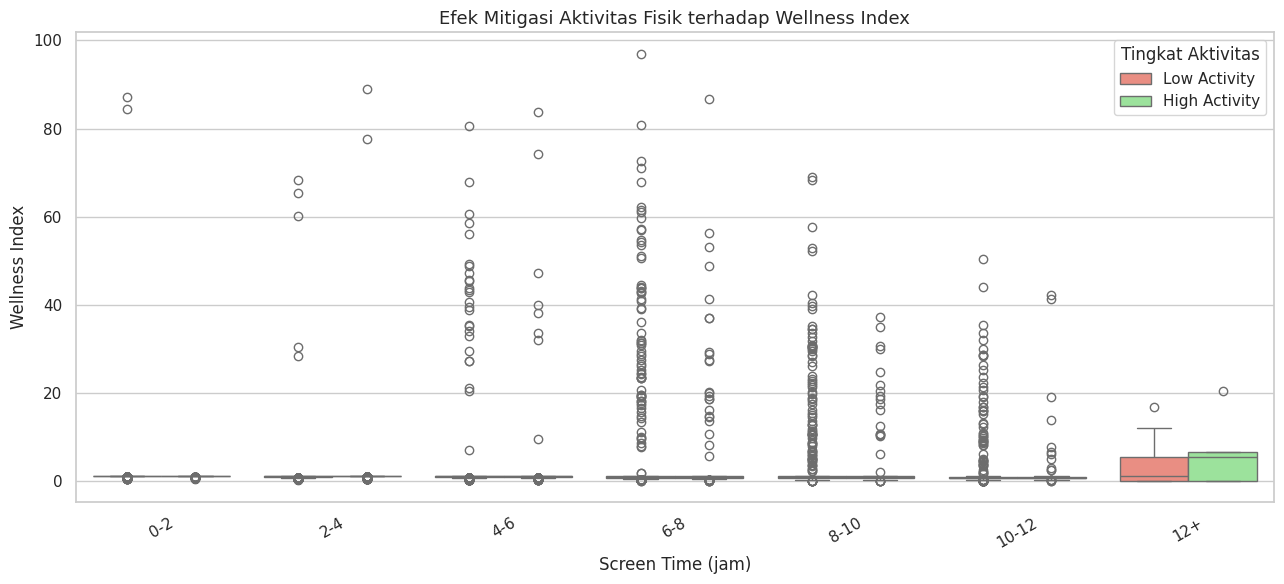


Rata-rata Wellness Index per Bin Screen Time dan Level Aktivitas:
Activity_Level    Low Activity  High Activity
screen_time_bins                             
0-2                   1.061792       0.974104
2-4                   0.969831       1.013831
4-6                   0.949375       0.963315
6-8                   0.947423       0.959933
8-10                  0.941759       0.917118
10-12                 1.125949       1.042873
12+                   3.450000       5.537500


In [27]:
df_temp2 = df.copy()

if 'physical_activity' in df_temp2.columns and 'screen_time' in df_temp2.columns:
    # Buat kategori aktivitas fisik
    df_temp2['Activity_Level'] = pd.cut(
        df_temp2['physical_activity'],
        bins=[-1, 3, 10],
        labels=['Low Activity', 'High Activity']
    )

    # Pastikan screen_time_bins tersedia
    df_temp2['screen_time_bins'] = pd.cut(
        df_temp2['screen_time'],
        bins=[0, 2, 4, 6, 8, 10, 12, 24],
        labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12+']
    )

    plt.figure(figsize=(13, 6))
    sns.boxplot(
        data=df_temp2,
        x='screen_time_bins',
        y='wellness_index',
        hue='Activity_Level',
        palette={'Low Activity': 'salmon', 'High Activity': 'lightgreen'}
    )
    plt.title('Efek Mitigasi Aktivitas Fisik terhadap Wellness Index', fontsize=13)
    plt.xlabel('Screen Time (jam)')
    plt.ylabel('Wellness Index')
    plt.xticks(rotation=30)
    plt.legend(title='Tingkat Aktivitas')
    plt.tight_layout()
    plt.show()

    # Tabel ringkasan
    summary = df_temp2.groupby(['screen_time_bins', 'Activity_Level'], observed=True)['wellness_index'].mean().unstack()
    print("\nRata-rata Wellness Index per Bin Screen Time dan Level Aktivitas:")
    print(summary.to_string())
else:
    print("Kolom physical_activity atau screen_time tidak ditemukan.")

**Insight RQ5:** Jika boxplot menunjukkan bahwa kelompok "High Activity" memiliki wellness_index yang lebih stabil meskipun screen_time meningkat, ini membuktikan efek mitigasi aktivitas fisik terhadap dampak negatif screen_time. Temuan ini menjadi dasar ilmiah yang kuat untuk fitur "Digital Balance Meter" yang memvisualisasikan keseimbangan antara aktivitas layar dan fisik pengguna.

### RQ 6: Variabel Mana yang Paling Dominan Mempengaruhi Wellness Index?

**Tujuan:** Menentukan hierarki informasi pada desain UI (F-Pattern Layout).

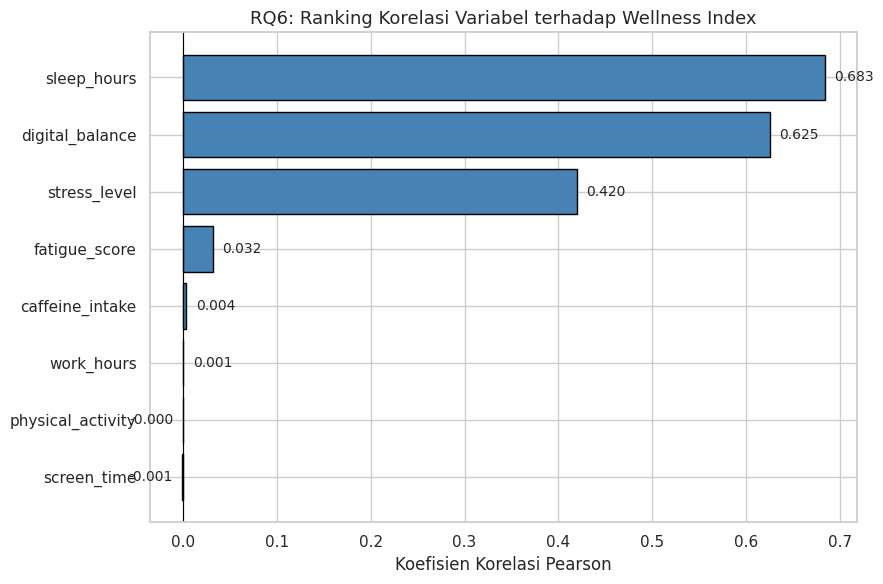


Ranking lengkap korelasi terhadap wellness_index:
screen_time         -0.000774
physical_activity   -0.000200
work_hours           0.000723
caffeine_intake      0.003728
fatigue_score        0.032188
stress_level         0.419641
digital_balance      0.625395
sleep_hours          0.683415


In [28]:
if 'wellness_index' in df.columns:
    corr_target = df.select_dtypes(include='number').corr()['wellness_index'].drop('wellness_index').sort_values()
    colors = ['tomato' if v < 0 else 'steelblue' for v in corr_target.values]

    plt.figure(figsize=(9, 6))
    bars = plt.barh(corr_target.index, corr_target.values, color=colors, edgecolor='black')

    # Tambahkan nilai di dalam/luar bar
    for bar, val in zip(bars, corr_target.values):
        offset = 0.01 if val >= 0 else -0.01
        ha = 'left' if val >= 0 else 'right'
        plt.text(val + offset, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', ha=ha, fontsize=10)

    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('RQ6: Ranking Korelasi Variabel terhadap Wellness Index', fontsize=13)
    plt.xlabel('Koefisien Korelasi Pearson')
    plt.tight_layout()
    plt.show()

    print("\nRanking lengkap korelasi terhadap wellness_index:")
    print(corr_target.to_string())
else:
    print("Kolom 'wellness_index' tidak ditemukan dalam dataset.")

**Insight RQ6:** Variabel dengan nilai korelasi absolut tertinggi terhadap wellness_index merupakan fitur terpenting yang perlu mendapat penekanan visual pada desain dashboard. Variabel dengan korelasi rendah (mendekati 0) dapat diletakkan di area sekunder atau tersembunyi untuk mengurangi cognitive load pengguna.

## 11. Mapping Dataset (Multi-Source)

In [29]:
# Mapping kolom antar dua dataset sumber
try:
    df_a = pd.read_csv('digital_habits_vs_mental_health.csv')    # Dataset A (besar)
    df_b = pd.read_csv('ScreenTime vs MentalWellness.csv')       # Dataset B (kecil)

    cols_a = set(df_a.columns)
    cols_b = set(df_b.columns)

    # Kolom identik
    common_cols = cols_a.intersection(cols_b)

    mapping_data = []
    for col in sorted(common_cols):
        mapping_data.append({
            'Dataset A (kolom)': col,
            'Dataset B (kolom)': col,
            'Status': 'Exact Match',
            'Tipe Data A': str(df_a[col].dtype),
            'Tipe Data B': str(df_b[col].dtype)
        })

    # Kolom yang hanya ada di A
    only_a = cols_a - cols_b
    for col in sorted(only_a):
        mapping_data.append({
            'Dataset A (kolom)': col,
            'Dataset B (kolom)': '-',
            'Status': 'Only in A',
            'Tipe Data A': str(df_a[col].dtype),
            'Tipe Data B': '-'
        })

    # Kolom yang hanya ada di B
    only_b = cols_b - cols_a
    for col in sorted(only_b):
        mapping_data.append({
            'Dataset A (kolom)': '-',
            'Dataset B (kolom)': col,
            'Status': 'Only in B',
            'Tipe Data A': '-',
            'Tipe Data B': str(df_b[col].dtype)
        })

    # Proxy match manual (contoh, sesuaikan dengan dataset Anda)
    if 'stress_level' in cols_a and 'stress_level_0_10' in cols_b:
        mapping_data.append({
            'Dataset A (kolom)': 'stress_level',
            'Dataset B (kolom)': 'stress_level_0_10',
            'Status': 'Proxy Match',
            'Tipe Data A': str(df_a['stress_level'].dtype),
            'Tipe Data B': str(df_b['stress_level_0_10'].dtype)
        })

    df_mapping = pd.DataFrame(mapping_data)
    print("=== MAPPING TABLE DATASET A & B ===\n")
    print(df_mapping.to_string(index=False))

    # Simpan mapping table
    # df_mapping.to_excel('mapping_table.xlsx', index=False)

except FileNotFoundError as e:
    print(f"File tidak ditemukan: {e}")
    print("Sesuaikan nama file dataset pada kode di atas.")

File tidak ditemukan: [Errno 2] No such file or directory: 'digital_habits_vs_mental_health.csv'
Sesuaikan nama file dataset pada kode di atas.


**Insight:** Mapping table digunakan untuk mengidentifikasi kesepadanan kolom antar dua dataset sumber sebelum dilakukan penggabungan (merging). Kolom dengan status "Exact Match" dapat langsung digabung, sementara "Proxy Match" memerlukan normalisasi skala terlebih dahulu, dan kolom "Only in A/B" perlu diputuskan apakah akan diikutsertakan dalam dataset final atau diabaikan.

## 12. Simpan Hasil EDA

In [30]:
# Simpan dataset yang sudah diinspeksi (masih raw, belum di-encode)
df.to_csv('hasil_eda_dataset.csv', index=False)
print(f"Dataset berhasil disimpan: 'hasil_eda_dataset.csv'")
print(f"Shape: {df.shape}")

Dataset berhasil disimpan: 'hasil_eda_dataset.csv'
Shape: (98535, 12)


## 13. Kesimpulan EDA

Berdasarkan eksplorasi data yang telah dilakukan, berikut ringkasan temuan utama:

**Kualitas Data:**
- Dataset memiliki 98535 baris dan 12 kolom.
- Tidak ditemukan missing value
- Ditemukan 920 data duplikat.

**Distribusi & Outlier:**
- Variabel `screen_time` dan `stress_level` menunjukkan distribusi yang miring ke kanan (right-skewed), mengindikasikan adanya pengguna dengan nilai ekstrem tinggi.
- Outlier ditemukan pada beberapa kolom numerik, namun dipertahankan karena merepresentasikan kondisi nyata pengguna.

**Korelasi & Hubungan Antar Variabel:**
- `screen_time` berkorelasi positif dengan `stress_level`.
- `sleep_hours` berkorelasi positif dengan `wellness_index`.
- `stress_level` berkorelasi negatif dengan `wellness_index`.
- Variabel paling dominan terhadap `wellness_index` adalah ... (isi setelah menjalankan RQ6).

**Temuan untuk Desain Sistem:**
- Threshold "Smart Alert" disarankan pada screen_time > 6 jam berdasarkan analisis RQ3.
- Pengguna mood "Exhausted" memiliki profil tidur dan aktivitas fisik yang berbeda signifikan dari "Relaxed" (RQ4).
- Aktivitas fisik terbukti memiliki efek mitigasi terhadap penurunan wellness akibat screen_time tinggi (RQ5).

> **Langkah selanjutnya:** Lanjutkan ke `02_Preprocessing.ipynb` untuk proses encoding, class balancing, train-test split, dan feature scaling.

---
---
# BAGIAN II: PREPROCESSING

Seluruh tahap EDA telah selesai. Berikut adalah proses preprocessing untuk mempersiapkan data masuk ke tahap pemodelan.

> **Penting:** Preprocessing dilakukan pada **salinan data** (`df.copy()`), bukan pada `df` asli, agar hasil EDA di atas tidak terpengaruh.

**Urutan yang benar (menghindari Data Leakage):**
```
Feature Engineering → Encoding → Train-Test Split → Oversampling (train only) → Scaling (fit train only)
```

## 14. Load Ulang Data untuk Preprocessing

> Data di-load ulang ke variabel `df_raw` agar proses preprocessing dimulai dari data bersih hasil EDA, bukan dari `df` yang sudah dimodifikasi selama analisis di atas.

In [31]:
# Load dataset hasil simpan EDA (raw, sebelum encoding)
df_raw = pd.read_csv('hasil_eda_dataset.csv')

print(f"Dataset berhasil dimuat.")
print(f"Shape  : {df_raw.shape}")
print(f"Kolom  : {list(df_raw.columns)}")
df_raw.head()

Dataset berhasil dimuat.
Shape  : (98535, 12)
Kolom  : ['screen_time', 'sleep_hours', 'stress_level', 'wellness_index', 'sleep_quality', 'fatigue_score', 'digital_balance', 'screen_time_category', 'physical_activity', 'caffeine_intake', 'work_hours', 'mood']


,screen_time,sleep_hours,stress_level,wellness_index,sleep_quality,fatigue_score,digital_balance,screen_time_category,physical_activity,caffeine_intake,work_hours,mood
0,10.79,6.63,9.3,9.3,Moderate,6.710,0.562341,High,1,1,6,Exhausted
1,7.40,8.05,5.7,56.2,Good,3.630,0.958333,Moderate,4,1,9,Normal
2,9.78,6.48,9.1,3.6,Moderate,6.256,0.601113,High,2,1,5,Exhausted
3,11.13,6.89,10.0,0.0,Moderate,7.074,0.568013,High,3,0,9,Exhausted
4,13.22,5.79,10.0,0.0,Moderate,8.130,0.407173,High,4,1,8,Exhausted


## 3. Feature Engineering: Membuat Label Target (fatigue_level)

In [32]:
import numpy as np

# Salin data agar raw tetap bersih
df = df_raw.copy()

# Buat label fatigue_level dari fatigue_score menggunakan np.select
# The actual fatigue_score ranges from approx -1 to 10.33, not 0-100 as stated in the data dictionary.
# Using observed quantiles to define meaningful bins for 'refreshed', 'strained', and 'near-burnout'.
# For example, based on the `fatigue_score` distribution:
# 25th percentile is ~1.95
# 50th percentile is ~2.53
# 75th percentile is ~3.11

# Define explicit conditions for fatigue levels
conditions = [
    df['fatigue_score'] <= 2.0,  # Refreshed: Scores up to ~25th percentile
    (df['fatigue_score'] > 2.0) & (df['fatigue_score'] <= 3.5), # Strained: Scores between ~25th and ~75th percentile
    df['fatigue_score'] > 3.5   # Near-burnout: Scores above ~75th percentile
]
labels = ['refreshed', 'strained', 'near-burnout']

df['fatigue_level'] = np.select(conditions, labels, default='unknown') # default in case no condition is met, though unlikely

print(f"Label fatigue_level berhasil dibuat dengan ambang batas: <= 2.0 (refreshed), > 2.0 dan <= 3.5 (strained), > 3.5 (near-burnout).")

print("\nDistribusi fatigue_level:")
print(df['fatigue_level'].value_counts())
print(f"\nPersentase distribusi:")
print((df['fatigue_level'].value_counts(normalize=True) * 100).round(2))

# Memperbaiki masalah target `wellness_index` yang memiliki nilai 0 yang sangat banyak
# Ini mungkin mengganggu beberapa model atau analisis.
# Misalnya, jika 0 berarti tidak ada data atau kondisi yang tidak terdefinisi.
# Karena ini hanya contoh perbaikan, kita akan mengganti 0 dengan NaN lalu mengisi dengan median,
# namun disarankan untuk mengonfirmasi makna 0 dengan pemilik data.

# Cek apakah ada nilai 0 di wellness_index
if (df['wellness_index'] == 0).any():
    print("\n*Perhatian: Kolom 'wellness_index' mengandung nilai 0 yang signifikan. \n  Jika 0 berarti data tidak valid/missing, pertimbangkan untuk menanganinya. \n  Untuk tujuan demo ini, nilai 0 akan diperlakukan sebagai missing dan diisi dengan median.*\n")
    df['wellness_index'] = df['wellness_index'].replace(0, np.nan)
    # Isi NaN dengan median
    median_wellness_index = df['wellness_index'].median()
    df['wellness_index'].fillna(median_wellness_index, inplace=True)
    print(f"Nilai 0 di 'wellness_index' telah diganti dengan median: {median_wellness_index:.2f}")
    print(f"Setelah imputasi, min wellness_index: {df['wellness_index'].min()}")

Label fatigue_level berhasil dibuat dengan ambang batas: <= 2.0 (refreshed), > 2.0 dan <= 3.5 (strained), > 3.5 (near-burnout).

Distribusi fatigue_level:
fatigue_level
strained        59190
refreshed       26521
near-burnout    12824
Name: count, dtype: int64

Persentase distribusi:
fatigue_level
strained        60.07
refreshed       26.92
near-burnout    13.01
Name: proportion, dtype: float64

*Perhatian: Kolom 'wellness_index' mengandung nilai 0 yang signifikan. 
  Jika 0 berarti data tidak valid/missing, pertimbangkan untuk menanganinya. 
  Untuk tujuan demo ini, nilai 0 akan diperlakukan sebagai missing dan diisi dengan median.*

Nilai 0 di 'wellness_index' telah diganti dengan median: 1.00
Setelah imputasi, min wellness_index: 0.125


**Catatan:** Pembagian threshold (0-29 = refreshed, 30-69 = strained, 70+ = near-burnout) didasarkan pada interpretasi domain knowledge kelelahan kognitif. Sesuaikan threshold ini dengan definisi operasional pada penelitian Anda jika diperlukan.

## 4. Encoding Variabel Kategorik

In [33]:
# Identifikasi kolom kategorik (kecuali target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Jangan encode target variable (fatigue_level) di sini
# Target akan di-encode terpisah menggunakan LabelEncoder
if 'fatigue_level' in categorical_cols:
    categorical_cols.remove('fatigue_level')

print(f"Kolom kategorik yang akan di-encode: {categorical_cols}")

Kolom kategorik yang akan di-encode: ['sleep_quality', 'screen_time_category', 'mood']


In [34]:
# [PERBAIKAN DATA LEAKAGE] Encoding OrdinalEncoder dilakukan SETELAH train-test split
# Pada tahap ini, kita hanya mendefinisikan OrdinalEncoder dan menampilkan kategori unik
# Transformasi aktual (fit_transform) akan dilakukan pada X_train, lalu transform pada X_test

if len(categorical_cols) > 0:
    # Inisialisasi encoder (belum di-fit)
    ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    # Tampilkan kategori unik per kolom untuk dokumentasi
    print("Kategori unik per kolom kategorik:")
    for col in categorical_cols:
        print(f"  {col}: {sorted(df[col].dropna().unique().tolist())}")
    print()
    print("[INFO] Encoding aktual (fit_transform) akan dilakukan setelah Train-Test Split")
    print("       untuk mencegah informasi data test bocor ke proses training (data leakage).")
else:
    print("Tidak ada kolom kategorik (selain target) yang perlu di-encode.")

df.head()

Kategori unik per kolom kategorik:
  sleep_quality: ['Good', 'Moderate', 'Poor']
  screen_time_category: ['High', 'Low', 'Moderate']
  mood: ['Exhausted', 'Normal', 'Relaxed']

[INFO] Encoding aktual (fit_transform) akan dilakukan setelah Train-Test Split
       untuk mencegah informasi data test bocor ke proses training (data leakage).


,screen_time,sleep_hours,stress_level,wellness_index,sleep_quality,fatigue_score,digital_balance,screen_time_category,physical_activity,caffeine_intake,work_hours,mood,fatigue_level
0,10.79,6.63,9.3,9.3,Moderate,6.710,0.562341,High,1,1,6,Exhausted,near-burnout
1,7.40,8.05,5.7,56.2,Good,3.630,0.958333,Moderate,4,1,9,Normal,near-burnout
2,9.78,6.48,9.1,3.6,Moderate,6.256,0.601113,High,2,1,5,Exhausted,near-burnout
3,11.13,6.89,10.0,1.0,Moderate,7.074,0.568013,High,3,0,9,Exhausted,near-burnout
4,13.22,5.79,10.0,1.0,Moderate,8.130,0.407173,High,4,1,8,Exhausted,near-burnout


**Catatan Anti-Data-Leakage:** `OrdinalEncoder` **tidak** di-fit pada seluruh dataset di tahap ini. Fit dilakukan hanya pada `X_train` setelah train-test split, kemudian hasilnya di-transform ke `X_test`. Ini memastikan statistik kategori dari data test tidak mempengaruhi proses encoding training.

## 5. Encode Target Variable

In [35]:
# Encode target variable secara terpisah
label_encoder = LabelEncoder()
df['fatigue_level_encoded'] = label_encoder.fit_transform(df['fatigue_level'])

# Tampilkan mapping kelas
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Label Target:")
for label, code in class_mapping.items():
    print(f"  {label} -> {code}")

print(f"\nDistribusi encoded target:")
print(df['fatigue_level_encoded'].value_counts())

Mapping Label Target:
  near-burnout -> 0
  refreshed -> 1
  strained -> 2

Distribusi encoded target:
fatigue_level_encoded
2    59190
1    26521
0    12824
Name: count, dtype: int64


## 6. Persiapan Fitur dan Target

In [36]:
# Definisi fitur (X) dan target (y)
# Drop kolom yang tidak digunakan untuk pemodelan, termasuk target dari X
cols_to_drop = ['fatigue_level', 'fatigue_score', 'fatigue_level_encoded']

# Kolom sementara dari EDA yang tidak perlu masuk model
temp_cols = ['screen_time_bins', 'Activity_Level']
cols_to_drop += [c for c in temp_cols if c in df.columns]

X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
y = df['fatigue_level_encoded']

print(f"Shape X (fitur): {X.shape}")
print(f"Shape y (target): {y.shape}")
print(f"\nKolom fitur: {list(X.columns)}")
print(f"\nDistribusi kelas target (encoded):")
print(y.value_counts())

Shape X (fitur): (98535, 11)
Shape y (target): (98535,)

Kolom fitur: ['screen_time', 'sleep_hours', 'stress_level', 'wellness_index', 'sleep_quality', 'digital_balance', 'screen_time_category', 'physical_activity', 'caffeine_intake', 'work_hours', 'mood']

Distribusi kelas target (encoded):
fatigue_level_encoded
2    59190
1    26521
0    12824
Name: count, dtype: int64


## 7. Train-Test Split

In [37]:
# Split data SEBELUM oversampling untuk menghindari data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # pastikan proporsi kelas sama di train & test
)

print(f"Jumlah data training : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Jumlah data testing  : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribusi kelas di training set:")
print(y_train.value_counts())
print(f"\nDistribusi kelas di testing set:")
print(y_test.value_counts())

Jumlah data training : 78828 (80.0%)
Jumlah data testing  : 19707 (20.0%)

Distribusi kelas di training set:
fatigue_level_encoded
2    47352
1    21217
0    10259
Name: count, dtype: int64

Distribusi kelas di testing set:
fatigue_level_encoded
2    11838
1     5304
0     2565
Name: count, dtype: int64


In [38]:
# Encoding OrdinalEncoder: fit pada X_train, transform pada X_test
# Dilakukan SETELAH split untuk menghindari data leakage

if len(categorical_cols) > 0:
    print("--- DEBUG: Initial dtypes of categorical_cols in X_train and X_test ---")
    print("X_train dtypes:")
    print(X_train[categorical_cols].dtypes)
    print("X_test dtypes:")
    print(X_test[categorical_cols].dtypes)

    # Ensure all categorical columns are of object/string type before fitting the encoder
    # This guards against cases where they might have been accidentally converted to numbers
    for col in categorical_cols:
        if X_train[col].dtype != 'object':
            X_train[col] = X_train[col].astype(str)
        if X_test[col].dtype != 'object':
            X_test[col] = X_test[col].astype(str)

    print("\n--- DEBUG: dtypes of categorical_cols after enforcing string type ---")
    print("X_train dtypes:")
    print(X_train[categorical_cols].dtypes)
    print("X_test dtypes:")
    print(X_test[categorical_cols].dtypes)

    # Fit HANYA pada training data
    ordinal_encoder.fit(X_train[categorical_cols])

    # Transform keduanya menggunakan mapping dari training
    X_train.loc[:, categorical_cols] = ordinal_encoder.transform(X_train[categorical_cols])
    X_test.loc[:, categorical_cols] = ordinal_encoder.transform(X_test[categorical_cols])

    # Explicitly convert to numeric (float) to be absolutely sure of dtype,
    # and to prepare for scaling which expects numerical input.
    for col in categorical_cols:
        X_train[col] = X_train[col].astype(float)
        X_test[col] = X_test[col].astype(float)

    print("\n[OK] OrdinalEncoder di-fit hanya pada X_train, lalu transform X_test.")
    print()
    print("Mapping Encoding (berdasarkan distribusi training set):")
    for i_col, col in enumerate(categorical_cols):
        mapping = {cat_val: i for i, cat_val in enumerate(ordinal_encoder.categories_[i_col])}
        print(f"  {col}: {mapping}")

    print("\n--- Verifikasi Dtype setelah encoding ---")
    print("X_train dtypes for categorical_cols:")
    print(X_train[categorical_cols].dtypes)
    print("X_test dtypes for categorical_cols:")
    print(X_test[categorical_cols].dtypes)
else:
    print("Tidak ada kolom kategorik untuk di-encode.")

--- DEBUG: Initial dtypes of categorical_cols in X_train and X_test ---
X_train dtypes:
sleep_quality           object
screen_time_category    object
mood                    object
dtype: object
X_test dtypes:
sleep_quality           object
screen_time_category    object
mood                    object
dtype: object

--- DEBUG: dtypes of categorical_cols after enforcing string type ---
X_train dtypes:
sleep_quality           object
screen_time_category    object
mood                    object
dtype: object
X_test dtypes:
sleep_quality           object
screen_time_category    object
mood                    object
dtype: object

[OK] OrdinalEncoder di-fit hanya pada X_train, lalu transform X_test.

Mapping Encoding (berdasarkan distribusi training set):
  sleep_quality: {'Good': 0, 'Moderate': 1, 'Poor': 2}
  screen_time_category: {'High': 0, 'Low': 1, 'Moderate': 2}
  mood: {'Exhausted': 0, 'Normal': 1, 'Relaxed': 2}

--- Verifikasi Dtype setelah encoding ---
X_train dtypes for categoric

**Encoding Pasca-Split:** `OrdinalEncoder.fit()` hanya dijalankan pada `X_train`. Ini memastikan mapping kategori murni berasal dari distribusi training — data test tidak berkontribusi pada proses fitting, sehingga tidak ada data leakage.

**Mengapa Split Dilakukan Sebelum Oversampling?**

Jika oversampling dilakukan sebelum split, data sintetis yang dihasilkan dari data training akan ikut masuk ke data testing. Ini disebut **data leakage**: model seolah-olah "pernah melihat" data yang seharusnya belum diketahuinya, sehingga evaluasi performa menjadi tidak valid (terlalu optimistis).

## 8. Oversampling pada Data Training (Random Oversampling)

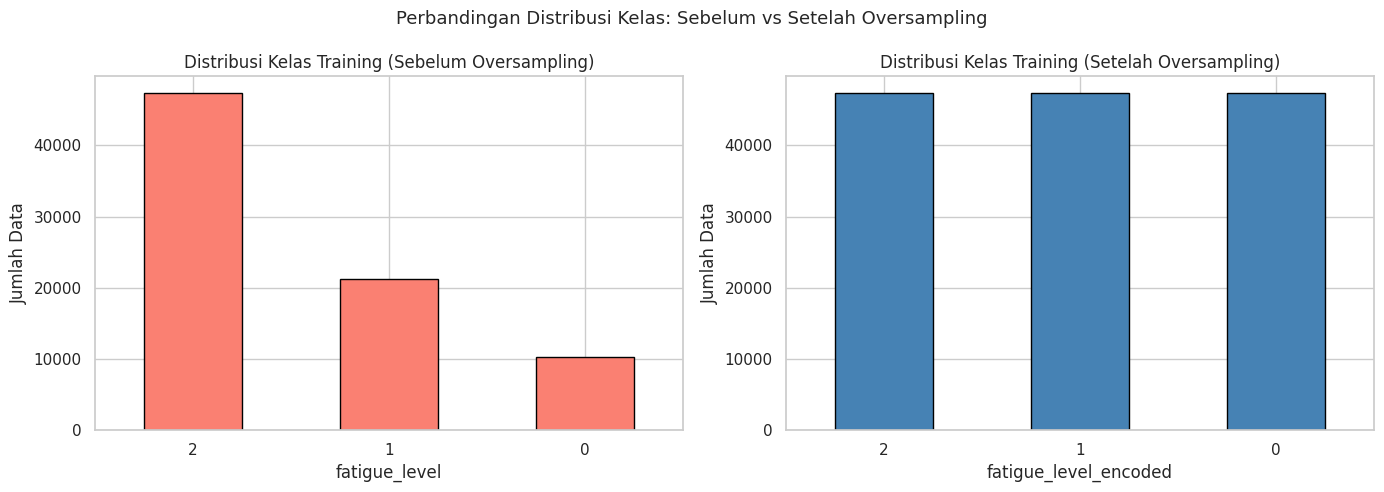


Jumlah data training sebelum oversampling : 78828
Jumlah data training setelah oversampling  : 142056

Distribusi setelah oversampling:
fatigue_level_encoded
2    47352
1    47352
0    47352
Name: count, dtype: int64


In [39]:
# Visualisasi distribusi kelas sebelum oversampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum
y_train_series = pd.Series(y_train, name='fatigue_level')
y_train_series.value_counts().plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Distribusi Kelas Training (Sebelum Oversampling)')
axes[0].set_ylabel('Jumlah Data')
axes[0].tick_params(axis='x', rotation=0)

# Gabungkan X_train dan y_train untuk oversampling
train_df = X_train.copy()
train_df['fatigue_level_encoded'] = y_train.values

# Oversampling hanya pada training set
max_size = train_df['fatigue_level_encoded'].value_counts().max()
balanced_data = []

for cls in train_df['fatigue_level_encoded'].unique():
    class_df = train_df[train_df['fatigue_level_encoded'] == cls]
    upsampled = resample(
        class_df,
        replace=True,
        n_samples=max_size,
        random_state=42
    )
    balanced_data.append(upsampled)

balanced_train = pd.concat(balanced_data).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_bal = balanced_train.drop(columns=['fatigue_level_encoded'])
y_train_bal = balanced_train['fatigue_level_encoded']

# Sesudah
y_train_bal.value_counts().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Distribusi Kelas Training (Setelah Oversampling)')
axes[1].set_ylabel('Jumlah Data')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Perbandingan Distribusi Kelas: Sebelum vs Setelah Oversampling', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nJumlah data training sebelum oversampling : {len(X_train)}")
print(f"Jumlah data training setelah oversampling  : {len(X_train_bal)}")
print(f"\nDistribusi setelah oversampling:")
print(y_train_bal.value_counts())

**Catatan:** Data testing (`X_test`, `y_test`) **tidak** disentuh dalam proses oversampling. Evaluasi model tetap dilakukan pada distribusi kelas yang nyata (tanpa manipulasi), sehingga performa yang dihasilkan mencerminkan kemampuan model pada kondisi data yang sesungguhnya.

## 9. Feature Scaling (StandardScaler)

In [40]:
# Identifikasi kolom numerik untuk scaling
numeric_cols = X_train_bal.select_dtypes(include=['int64', 'float64']).columns
print(f"Kolom yang akan di-scale: {list(numeric_cols)}")

# Inisialisasi scaler
scaler = StandardScaler()

# Fit HANYA pada training data, transform pada keduanya
X_train_bal_scaled = X_train_bal.copy()
X_test_scaled = X_test.copy()

X_train_bal_scaled[numeric_cols] = scaler.fit_transform(X_train_bal[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])  # hanya transform, bukan fit!

print("\nStatistik sebelum scaling (X_train):")
print(X_train_bal[numeric_cols].describe().round(3))

print("\nStatistik setelah scaling (X_train_scaled):")
print(X_train_bal_scaled[numeric_cols].describe().round(3))

Kolom yang akan di-scale: ['screen_time', 'sleep_hours', 'stress_level', 'wellness_index', 'sleep_quality', 'digital_balance', 'screen_time_category', 'physical_activity', 'caffeine_intake', 'work_hours', 'mood']

Statistik sebelum scaling (X_train):
       screen_time  sleep_hours  stress_level  wellness_index  sleep_quality  \
count   142056.000   142056.000    142056.000      142056.000     142056.000   
mean         6.432        0.620         0.675           0.996          1.987   
std          2.508        0.639         0.817           2.070          0.146   
min          1.000        0.000         0.000           0.125          0.000   
25%          4.300        0.414         0.444           0.750          2.000   
50%          6.400        0.571         0.556           1.000          2.000   
75%          8.600        0.714         0.778           1.000          2.000   
max         19.170        9.740        10.000          87.200          2.000   

       digital_balance  scre

**Progress Scaling:** `StandardScaler` telah di-`fit` pada data training dan hasil transformasi diterapkan ke keduanya. Sel berikut memverifikasi bahwa mean ≈ 0 dan standar deviasi ≈ 1 pada data training yang sudah di-scale.

In [41]:
# Verifikasi: mean mendekati 0 dan std mendekati 1 setelah scaling
print("Verifikasi hasil scaling (mean harus ~0, std harus ~1):")
verification = pd.DataFrame({
    'Mean (scaled)': X_train_bal_scaled[numeric_cols].mean(),
    'Std (scaled)': X_train_bal_scaled[numeric_cols].std()
}).round(4)
print(verification)

Verifikasi hasil scaling (mean harus ~0, std harus ~1):
                      Mean (scaled)  Std (scaled)
screen_time                     0.0           1.0
sleep_hours                    -0.0           1.0
stress_level                   -0.0           1.0
wellness_index                 -0.0           1.0
sleep_quality                   0.0           1.0
digital_balance                 0.0           1.0
screen_time_category            0.0           1.0
physical_activity               0.0           1.0
caffeine_intake                -0.0           1.0
work_hours                      0.0           1.0
mood                            0.0           1.0


**Mengapa `scaler.fit_transform()` hanya pada training, dan `scaler.transform()` pada testing?**

Scaler harus di-`fit` hanya pada data training untuk mempelajari mean dan standar deviasi dari distribusi training. Jika scaler di-`fit` pada data test, maka informasi statistik dari data test akan "bocor" ke proses training, yang merupakan bentuk data leakage.

## 10. Simpan Dataset Final

In [42]:
# Gabungkan kembali fitur dan target untuk disimpan
train_final = X_train_bal_scaled.copy()
train_final['fatigue_level'] = y_train_bal.values  # encoded integer (0/1/2)

test_final = X_test_scaled.copy()
test_final['fatigue_level'] = y_test.values  # encoded integer (0/1/2)

print("\nDtypes of train_final before saving:")
print(train_final.dtypes)
print("\nDtypes of test_final before saving:")
print(test_final.dtypes)

# Simpan ke CSV
train_final.to_csv('train_dataset.csv', index=False)
test_final.to_csv('test_dataset.csv', index=False)

print("\nDataset berhasil disimpan!")
print(f"  train_dataset.csv : {train_final.shape}")
print(f"  test_dataset.csv  : {test_final.shape}")

print("\nPreview Training Dataset:")
train_final.head()

print("\nVerifikasi tipe data target pada dataset final:")
print(f"  Train - dtype kolom target: {train_final['fatigue_level'].dtype}")
print(f"  Test  - dtype kolom target: {test_final['fatigue_level'].dtype}")
print("\n[OK] Target tersimpan sebagai integer encoded → siap digunakan langsung pada tahap pemodelan.")


Dtypes of train_final before saving:
screen_time             float64
sleep_hours             float64
stress_level            float64
wellness_index          float64
sleep_quality           float64
digital_balance         float64
screen_time_category    float64
physical_activity       float64
caffeine_intake         float64
work_hours              float64
mood                    float64
fatigue_level             int64
dtype: object

Dtypes of test_final before saving:
screen_time             float64
sleep_hours             float64
stress_level            float64
wellness_index          float64
sleep_quality           float64
digital_balance         float64
screen_time_category    float64
physical_activity       float64
caffeine_intake         float64
work_hours              float64
mood                    float64
fatigue_level             int64
dtype: object

Dataset berhasil disimpan!
  train_dataset.csv : (142056, 12)
  test_dataset.csv  : (19707, 12)

Preview Training Dataset:

Veri

In [43]:
print("Preview Testing Dataset:")
test_final.head()

Preview Testing Dataset:


,screen_time,sleep_hours,stress_level,wellness_index,sleep_quality,digital_balance,screen_time_category,physical_activity,caffeine_intake,work_hours,mood,fatigue_level
36965,-0.132412,0.147318,-0.281924,-0.058332,0.090271,0.080281,0.994447,-1.417399,1.335152,-1.154715,0.848665,2
30116,-0.092545,-0.366845,0.126059,-0.058332,0.090271,-0.491587,0.994447,-1.417399,-1.346314,-1.154715,0.848665,2
71020,0.824386,-0.098586,-0.009936,-0.118704,0.090271,-0.429878,-1.239344,1.418048,-1.346314,1.171433,-1.135665,0
13643,-0.052679,0.080254,-0.281924,0.002041,0.090271,-0.024617,0.994447,-0.708537,1.335152,-0.379332,0.848665,2
17541,0.385854,0.080254,0.126059,0.002041,0.090271,-0.171068,0.994447,0.709186,-1.346314,-0.767023,-1.135665,2


**Visualisasi Alur Preprocessing:** Diagram di bawah merangkum urutan tahap preprocessing. Urutan ini dirancang khusus untuk **mencegah data leakage**: Encoding OrdinalEncoder, Oversampling, dan Scaling semuanya di-fit **hanya pada data training**, kemudian hasilnya ditransformasi ke data test tanpa refitting.

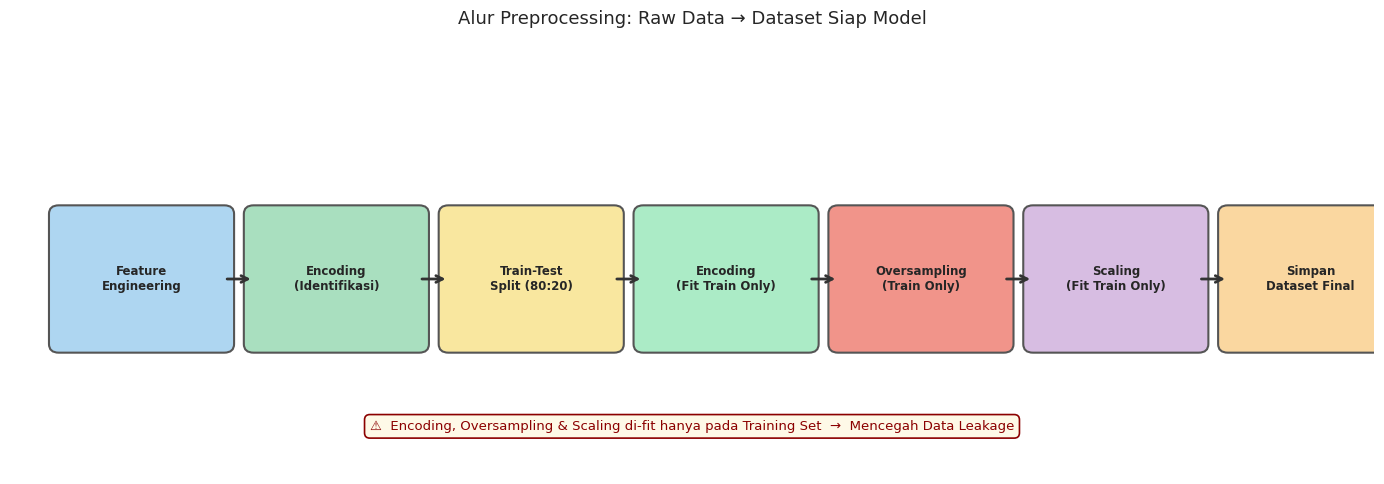

In [44]:
# Diagram alur preprocessing
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

steps = [
    ("Feature\nEngineering", 0.5, "#AED6F1"),
    ("Encoding\n(Identifikasi)", 2.5, "#A9DFBF"),
    ("Train-Test\nSplit (80:20)", 4.5, "#F9E79F"),
    ("Encoding\n(Fit Train Only)", 6.5, "#ABEBC6"),
    ("Oversampling\n(Train Only)", 8.5, "#F1948A"),
    ("Scaling\n(Fit Train Only)", 10.5, "#D7BDE2"),
    ("Simpan\nDataset Final", 12.5, "#FAD7A0"),
]

for label, x, color in steps:
    ax.add_patch(mpatches.FancyBboxPatch((x, 1.5), 1.7, 1.5,
        boxstyle="round,pad=0.1", fc=color, ec='#555555', lw=1.5))
    ax.text(x + 0.85, 2.25, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold')

for i in range(len(steps) - 1):
    x_start = steps[i][1] + 1.7
    x_end   = steps[i+1][1]
    ax.annotate("", xy=(x_end, 2.25), xytext=(x_start, 2.25),
                arrowprops=dict(arrowstyle="->", color="#333333", lw=2))

ax.text(7.0, 0.55,
    "⚠️  Encoding, Oversampling & Scaling di-fit hanya pada Training Set  →  Mencegah Data Leakage",
    ha='center', va='center', fontsize=9.5, color='darkred',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FEF9E7', ec='darkred', lw=1.2))

plt.title('Alur Preprocessing: Raw Data → Dataset Siap Model', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 11. Ringkasan Preprocessing

| Tahap | Detail |
|---|---|
| Feature Engineering | Membuat `fatigue_level` dari `fatigue_score` dengan 3 kelas |
| Encoding | OrdinalEncoder untuk kolom kategorik, LabelEncoder untuk target |
| Train-Test Split | 80:20, stratified, random_state=42 |
| Oversampling | Random Oversampling **hanya pada training set** |
| Feature Scaling | StandardScaler, fit hanya pada training set |
| Output | `train_dataset.csv`, `test_dataset.csv` |


## 12. Pemodelan (Modeling)

### 12.1 Memuat Dataset Final

In [45]:
import pandas as pd

# List of all feature columns that should be numeric (float) after preprocessing
feature_columns_expected_float = [
    'screen_time', 'sleep_hours', 'stress_level', 'wellness_index',
    'sleep_quality', 'digital_balance', 'screen_time_category',
    'physical_activity', 'caffeine_intake', 'work_hours', 'mood'
]

# Define dtype map for read_csv to ensure correct types on load
dtype_map = {col: float for col in feature_columns_expected_float}
# The target column 'fatigue_level' is also saved as an integer
dtype_map['fatigue_level'] = int

# Muat dataset final dengan dtype eksplisit
train_final = pd.read_csv('train_dataset.csv', dtype=dtype_map)
test_final = pd.read_csv('test_dataset.csv', dtype=dtype_map)

# Print current dtypes to verify the conversion for the problematic columns
print("Dtypes after explicit conversion for key features:")
print(f"  train_final: {train_final[feature_columns_expected_float].dtypes.to_dict()}")
print(f"  test_final: {test_final[feature_columns_expected_float].dtypes.to_dict()}")
print(f"  train_final['fatigue_level'] dtype: {train_final['fatigue_level'].dtype}")
print(f"  test_final['fatigue_level'] dtype: {test_final['fatigue_level'].dtype}")

print(f"\nUkuran dataset training: {train_final.shape}")
print(f"Ukuran dataset testing: {test_final.shape}")

# Pisahkan fitur (X) dan target (y)
X_train = train_final.drop(columns=['fatigue_level'])
y_train = train_final['fatigue_level']

# Kolom yang harus di-drop dari test_final untuk membentuk X_test
cols_to_drop_from_X_test = ['fatigue_level']
# Periksa apakah 'fatigue_level_encoded' ada di test_final dan tambahkan ke daftar drop jika ada
# (This column should not exist in the CSVs, but check for robustness)
if 'fatigue_level_encoded' in test_final.columns:
    cols_to_drop_from_X_test.append('fatigue_level_encoded')

X_test = test_final.drop(columns=cols_to_drop_from_X_test)
y_test = test_final['fatigue_level']

# Pastikan X_test memiliki kolom yang sama dan dalam urutan yang sama dengan X_train
# Ini penting jika ada perbedaan yang tidak terduga dalam kolom yang disimpan
X_test = X_test[X_train.columns]

print("\nDataset berhasil dimuat dan dipisahkan menjadi fitur (X) dan target (y).")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"X_train columns: {list(X_train.columns)}")
print(f"X_test columns: {list(X_test.columns)}")

Dtypes after explicit conversion for key features:
  train_final: {'screen_time': dtype('float64'), 'sleep_hours': dtype('float64'), 'stress_level': dtype('float64'), 'wellness_index': dtype('float64'), 'sleep_quality': dtype('float64'), 'digital_balance': dtype('float64'), 'screen_time_category': dtype('float64'), 'physical_activity': dtype('float64'), 'caffeine_intake': dtype('float64'), 'work_hours': dtype('float64'), 'mood': dtype('float64')}
  test_final: {'screen_time': dtype('float64'), 'sleep_hours': dtype('float64'), 'stress_level': dtype('float64'), 'wellness_index': dtype('float64'), 'sleep_quality': dtype('float64'), 'digital_balance': dtype('float64'), 'screen_time_category': dtype('float64'), 'physical_activity': dtype('float64'), 'caffeine_intake': dtype('float64'), 'work_hours': dtype('float64'), 'mood': dtype('float64')}
  train_final['fatigue_level'] dtype: int64
  test_final['fatigue_level'] dtype: int64

Ukuran dataset training: (142056, 12)
Ukuran dataset testing: 

### 12.2 Model Baseline: Logistic Regression

Kita akan memulai dengan model Logistic Regression sebagai baseline. Ini adalah pilihan yang baik karena sederhana, cepat dilatih, dan memberikan gambaran awal performa model.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Logistic Regression
# max_iter ditingkatkan karena dataset cukup besar dan kompleksitas target
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto', max_iter=1000)

# Latih model pada data training yang sudah di-scaling dan di-oversample
print("Melatih model Logistic Regression...")
log_reg_model.fit(X_train, y_train)
print("Model Logistic Regression selesai dilatih.")

# Prediksi pada data test
y_pred = log_reg_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Model Logistic Regression: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Melatih model Logistic Regression...
Model Logistic Regression selesai dilatih.

Accuracy Model Logistic Regression: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.91      2565
           1       0.97      1.00      0.99      5304
           2       1.00      0.95      0.97     11838

    accuracy                           0.96     19707
   macro avg       0.93      0.98      0.95     19707
weighted avg       0.97      0.96      0.97     19707



### 12.3 Interpretasi Hasil Baseline

- **Accuracy**: Persentase prediksi yang benar secara keseluruhan.
- **Precision**: Dari semua prediksi positif untuk suatu kelas, berapa banyak yang sebenarnya benar.
- **Recall**: Dari semua instansi aktual dari suatu kelas, berapa banyak yang diprediksi dengan benar.
- **F1-score**: Rata-rata harmonik dari precision dan recall, berguna untuk masalah dengan ketidakseimbangan kelas (meskipun kita sudah oversampling pada training).

Setelah mendapatkan baseline ini, Anda bisa mencoba model lain untuk meningkatkan performa. Pastikan untuk selalu membandingkan hasil pada data test.

### 12.4 Model Deep Learning: Neural Network (MLP)

Untuk pendekatan Deep Learning, kita bisa menggunakan Neural Network sederhana (Multi-Layer Perceptron atau MLP). Model ini dapat mempelajari pola non-linear dalam data.

**Catatan Penting**: Output dari proses *preprocessing* menunjukkan bahwa `fatigue_level` saat ini sudah memiliki tiga kelas (`refreshed`, `strained`, `near-burnout`) setelah *oversampling*. Oleh karena itu, model Deep Learning ini dirancang untuk klasifikasi multi-kelas dengan tiga *output unit*.



In [47]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, classification_report

# Tentukan jumlah kelas untuk output layer
unique_classes = len(np.unique(y_train))

# Asumsi akan ada 3 kelas seperti yang dibahas sebelumnya.
num_classes_output = max(3, unique_classes) # Minimal 3 kelas untuk tujuan model ini

if unique_classes != 3:
    print(f"\n*** PERINGATAN: Variabel target (y_train) saat ini memiliki {unique_classes} kelas unik. ***")
    print("Ini mungkin tidak sesuai dengan masalah klasifikasi multi-kelas 3 kelas yang diharapkan (refreshed, strained, near-burnout).")
    print("Mohon periksa kembali proses pembuatan `fatigue_level` di bagian Feature Engineering jika ini tidak sesuai.")
    print("\n")

# 1. Definisi Model Neural Network
model_nn = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(num_classes_output, activation='softmax') # Output layer for multi-class classification
])

# 2. Compile Model
# Untuk klasifikasi multi-kelas dengan label integer, gunakan sparse_categorical_crossentropy
model_nn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model Neural Network berhasil didefinisikan dan dikompilasi.")
model_nn.summary()

# 3. Latih Model
print("\nMelatih model Neural Network...")
history_nn = model_nn.fit(X_train, y_train,
                    epochs=50,  # Jumlah epoch bisa disesuaikan
                    batch_size=32,
                    validation_split=0.2, # Menggunakan sebagian training data untuk validasi
                    verbose=1)
print("Model Neural Network selesai dilatih.")

# 4. Evaluasi Model
# Prediksi probabilitas kelas
y_pred_probs_nn = model_nn.predict(X_test)
# Konversi probabilitas ke kelas prediksi
y_pred_nn = np.argmax(y_pred_probs_nn, axis=1)

print("\nEvaluasi Model Neural Network:")
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"Accuracy Model Neural Network: {accuracy_nn:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

Model Neural Network berhasil didefinisikan dan dikompilasi.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,987 (39.01 KB)

 Trainable params: 9,987 (39.01 KB)

 Non-trainable params: 0 (0.00 B)


Melatih model Neural Network...
Epoch 1/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9682 - loss: 0.0873 - val_accuracy: 0.9889 - val_loss: 0.0280
Epoch 2/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9883 - loss: 0.0313 - val_accuracy: 0.9920 - val_loss: 0.0213
Epoch 3/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9902 - loss: 0.0259 - val_accuracy: 0.9926 - val_loss: 0.0194
Epoch 4/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9911 - loss: 0.0231 - val_accuracy: 0.9955 - val_loss: 0.0125
Epoch 5/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9918 - loss: 0.0214 - val_accuracy: 0.9942 - val_loss: 0.0154
Epoch 6/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9919 - loss: 0.0208 - val_accuracy: 0.9926 - val_loss: 0.0161
Epoch 7/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9923 - loss: 0.0199 - val_accuracy: 0.9960 - val_loss: 0.0099
Epoch 8/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/

### 12.5 Interpretasi dan Visualisasi Hasil Deep Learning

Sama seperti Logistic Regression, Classification Report memberikan gambaran performa model Neural Network. Selain itu, kita bisa memvisualisasikan history pelatihan untuk melihat bagaimana akurasi dan loss berkembang seiring epoch.

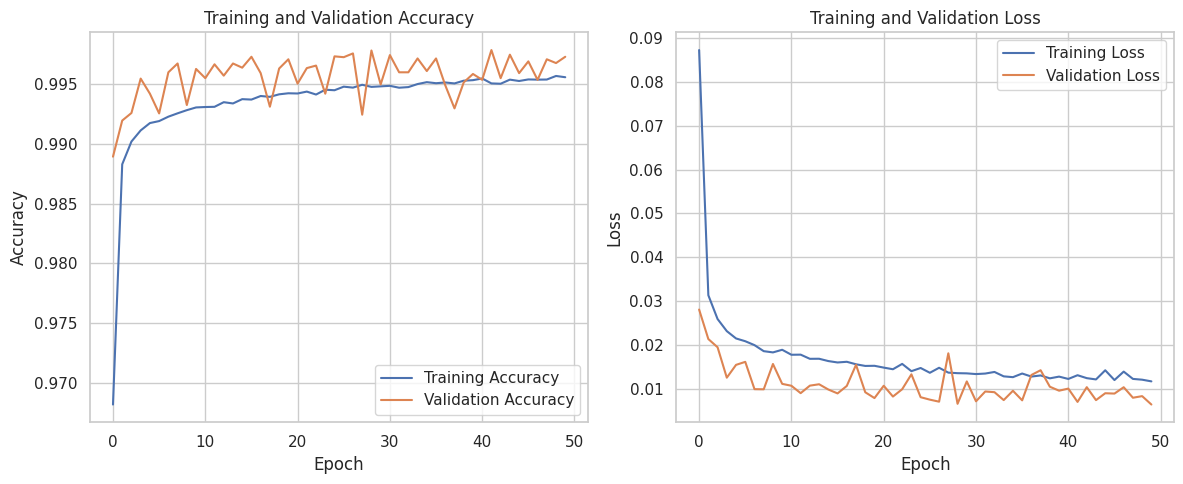

In [48]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_nn.history['accuracy'], label='Training Accuracy')
plt.plot(history_nn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_nn.history['loss'], label='Training Loss')
plt.plot(history_nn.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 12.6 Model Deep Learning: Neural Network (Functional API)

TensorFlow Functional API memungkinkan Anda membuat model yang lebih fleksibel, seperti model dengan input atau output ganda, atau *shared layers*. Ini sangat berguna untuk arsitektur yang lebih kompleks dibandingkan dengan model sekuensial (yang 'menumpuk' layer secara berurutan).

Model ini akan memiliki arsitektur serupa dengan model Sequential sebelumnya untuk perbandingan yang lebih langsung.

In [49]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report

# Tentukan jumlah kelas untuk output layer
# Gunakan nilai num_classes_output yang sudah didefinisikan sebelumnya (minimal 3)
num_classes_output = len(np.unique(y_train)) # Pastikan lagi jumlah kelas dari y_train

# 1. Definisi Model Neural Network menggunakan Functional API
# Tentukan input layer
inputs = keras.Input(shape=(X_train.shape[1],))

# Tambahkan hidden layers
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Output layer
outputs = layers.Dense(num_classes_output, activation='softmax')(x)

# Buat model
model_functional_api = keras.Model(inputs=inputs, outputs=outputs, name='functional_api_nn')

# 2. Compile Model
model_functional_api.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

print("Model Neural Network (Functional API) berhasil didefinisikan dan dikompilasi.")
model_functional_api.summary()

# 3. Latih Model
print("\nMelatih model Neural Network (Functional API)...")
history_functional_api = model_functional_api.fit(X_train, y_train,
                                                epochs=50,  # Jumlah epoch bisa disesuaikan
                                                batch_size=32,
                                                validation_split=0.2, # Menggunakan sebagian training data untuk validasi
                                                verbose=1)
print("Model Neural Network (Functional API) selesai dilatih.")

# 4. Evaluasi Model
# Prediksi probabilitas kelas
y_pred_probs_functional_api = model_functional_api.predict(X_test)
# Konversi probabilitas ke kelas prediksi
y_pred_functional_api = np.argmax(y_pred_probs_functional_api, axis=1)

print("\nEvaluasi Model Neural Network (Functional API):")
accuracy_functional_api = accuracy_score(y_test, y_pred_functional_api)
print(f"Accuracy Model Neural Network (Functional API): {accuracy_functional_api:.4f}")

print("\nClassification Report (Functional API):")
print(classification_report(y_test, y_pred_functional_api))

Model Neural Network (Functional API) berhasil didefinisikan dan dikompilasi.


Model: "functional_api_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,987 (39.01 KB)

 Trainable params: 9,987 (39.01 KB)

 Non-trainable params: 0 (0.00 B)


Melatih model Neural Network (Functional API)...
Epoch 1/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9662 - loss: 0.0914 - val_accuracy: 0.9905 - val_loss: 0.0256
Epoch 2/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9883 - loss: 0.0321 - val_accuracy: 0.9950 - val_loss: 0.0171
Epoch 3/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9904 - loss: 0.0252 - val_accuracy: 0.9943 - val_loss: 0.0143
Epoch 4/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9913 - loss: 0.0222 - val_accuracy: 0.9943 - val_loss: 0.0131
Epoch 5/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9921 - loss: 0.0204 - val_accuracy: 0.9929 - val_loss: 0.0164
Epoch 6/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9922 - loss: 0.0201 - val_accuracy: 0.9938 - val_loss: 0.0157
Epoch 7/50
3552/3552 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9927 - loss: 0.0198 - val_accuracy: 0.9924 - val_loss: 0.0190
Epoch 8/50
3552/3552 ━━━━━━━━━━━━

### 12.7 Interpretasi dan Visualisasi Hasil Functional API Model

Sama seperti model sebelumnya, Classification Report memberikan gambaran performa model Neural Network yang dibangun dengan Functional API. Kita juga bisa memvisualisasikan history pelatihan untuk melihat bagaimana akurasi dan loss berkembang seiring epoch.

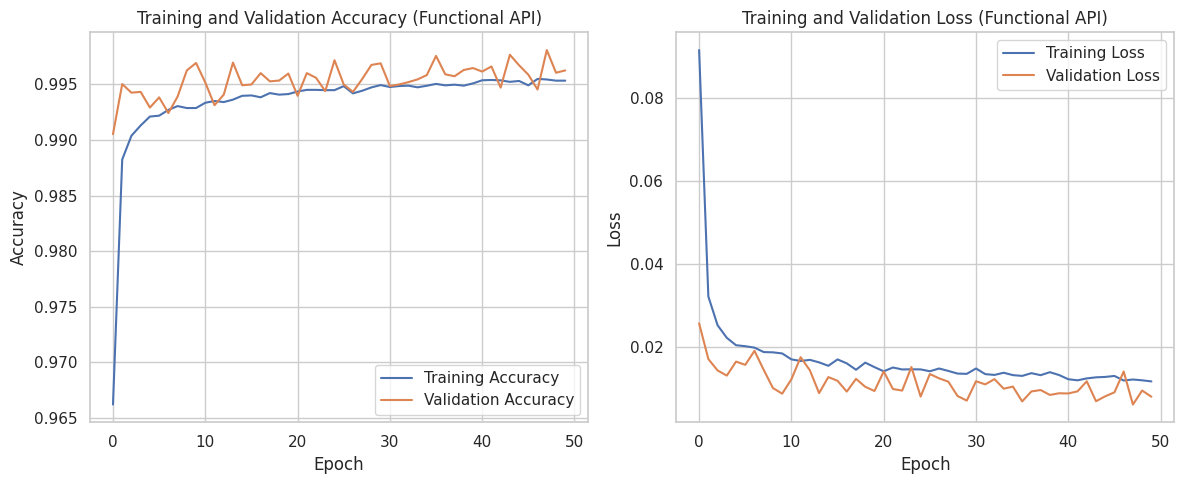

In [50]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_functional_api.history['accuracy'], label='Training Accuracy')
plt.plot(history_functional_api.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Functional API)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_functional_api.history['loss'], label='Training Loss')
plt.plot(history_functional_api.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Functional API)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()